# Evaluación de la extracción y construcción del universo documental

Este notebook documenta la primera etapa cuantitativa del TFM: desde los **registros procesados por el sistema de adquisición** hasta la obtención del **universo documental consolidado** que será entregado al procesamiento y a la preselección temática.

La secuencia que se quiere hacer explícita es:

$$
\text{registros procesados}
\longrightarrow
\text{extracciones válidas}
\longrightarrow
\text{documentos únicos consolidados}
$$

Es importante mantener separados estos niveles. Un registro procesado representa un intento de recuperación asociado a una captura; una extracción válida indica que se obtuvo texto utilizable; y un documento único corresponde al resultado de consolidar las extracciones válidas eliminando repeticiones documentales.

En este notebook **no se decide todavía qué noticias son relevantes para el objeto de estudio**. Esa decisión comienza en el notebook 03.


## 1. Configuración

El notebook intenta localizar automáticamente archivos `.csv`, `.csv.gz` y `.parquet` dentro de `data/`.

La estructura está preparada para un pipeline como:

`CDX → candidatos de portada → candidatos limpios → extracción de artículos → corpus relevante`



In [1]:

from pathlib import Path
import re
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


def find_repo_root():
    """
    Localiza la raíz de tfm-media-violence-analysis buscando
    simultáneamente src/ y outputs/.
    """
    here = Path.cwd().resolve()

    for candidate in [here, *here.parents]:
        if (candidate / "src").exists() and (candidate / "outputs").exists():
            return candidate

    raise RuntimeError(
        "No se pudo localizar la raíz del repositorio. "
        "Ejecuta el notebook dentro de tfm-media-violence-analysis."
    )


ROOT = find_repo_root()

# Debe hacerse antes de importar módulos propios del proyecto.
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


# ---------------------------------------------------------------------
# DIRECTORIOS DEL PROYECTO
# ---------------------------------------------------------------------
REPORTS_DIR = ROOT / "outputs" / "reports"
FINAL_DIR = ROOT / "outputs" / "final"
RUNS_DIR = ROOT / "data" / "runs"
EVIDENCE_DIR = ROOT / "docs" / "evidence"

# Salidas específicas de este notebook.
EXTRACTION_RESULTS_DIR = REPORTS_DIR / "extraction_performance"
EXTRACTION_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Alias usado por las celdas de gráficos.
OUTPUT_DIR = EXTRACTION_RESULTS_DIR

RESULTS_DIR = REPORTS_DIR / "extraction_performance"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

CONTEXTUAL_PATH = (
    REPORTS_DIR
    / "articles_contextual_unique.parquet"
)


# Evidencia/resumen generado por el pipeline.
EXTRACTION_SUMMARY_PATH = EVIDENCE_DIR / "extraction_summary.csv"

# ---------------------------------------------------------------------
# PERIODO DE ESTUDIO
# ---------------------------------------------------------------------
START_YEAR = 2015
END_YEAR = 2025


# ---------------------------------------------------------------------
# UMBRALES TÉCNICOS PARA CONTROL DE CALIDAD
# ---------------------------------------------------------------------
# Son umbrales diagnósticos, no una definición universal de calidad.
QUALITY_THRESHOLDS = {
    "very_short_max_words": 99,
    "short_max_words": 299,
    "long_min_words": 1500,
}


# ---------------------------------------------------------------------
# EXPORTACIÓN DE FIGURAS
# ---------------------------------------------------------------------
SAVE_FIGURES = True
DPI = 300


print("ROOT:", ROOT)
print("RUNS_DIR:", RUNS_DIR)
print("REPORTS_DIR:", REPORTS_DIR)
print("EVIDENCE_DIR:", EVIDENCE_DIR)
print("Salidas de este notebook:", EXTRACTION_RESULTS_DIR)
print("EXTRACTION_SUMMARY_PATH:", EXTRACTION_SUMMARY_PATH)

ROOT: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis
RUNS_DIR: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\data\runs
REPORTS_DIR: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\outputs\reports
EVIDENCE_DIR: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\docs\evidence
Salidas de este notebook: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\outputs\reports\extraction_performance
EXTRACTION_SUMMARY_PATH: C:\Users\Usuario\git\msc-viu\tfm-media-violence-analysis\docs\evidence\extraction_summary.csv


In [2]:
from src.visualization.palette import COLORS

### 2. Fuentes y funciones auxiliares

In [3]:
SOURCE_COUNTRY = {
    "clarin_arg": "Argentina",
    "lanacion": "Argentina",
    "pagina12": "Argentina",
    "jornada": "México",
    "milenio": "México",
    "eluniversal_mx": "México",
}

SOURCE_LABEL = {
    "clarin_arg": "Clarín",
    "lanacion": "La Nación",
    "pagina12": "Página/12",
    "jornada": "La Jornada",
    "milenio": "Milenio",
    "eluniversal_mx": "El Universal",
}

SOURCE_ORDER = {
    "Argentina": ["Clarín", "La Nación", "Página/12"],
    "México": ["Milenio", "El Universal", "La Jornada"],
}

ALL_NEWSPAPERS = (
    SOURCE_ORDER["Argentina"]
    + SOURCE_ORDER["México"]
)

SOURCE_COLORS = {
    "Argentina": [
        "#B9DFF1",
        COLORS["argentina"],
        COLORS["argentina_dark"],
    ],
    "México": [
        "#9ACBAD",
        COLORS["mexico"],
        COLORS["mexico_dark"],
    ],
}

NEWSPAPER_COLOR = {
    newspaper: color
    for country in SOURCE_ORDER
    for newspaper, color in zip(
        SOURCE_ORDER[country],
        SOURCE_COLORS[country],
    )
}


def fmt_int(x):
    return f"{int(round(x)):,}".replace(",", ".")


def safe_rate(num, den, scale=100):
    if den == 0:
        return np.nan
    return scale * num / den


def fmt_pct(x, decimals=1):
    return f"{x:.{decimals}f}%"


def assert_columns(df, required, name):
    missing = [
        c
        for c in required
        if c not in df.columns
    ]

    if missing:
        raise KeyError(
            f"{name}: faltan columnas requeridas: {missing}"
        )


def nonempty_text_mask(df, text_col="text"):
    return (
        df[text_col]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )


def no_fetch_error_mask(df, error_col="fetch_error"):
    if error_col not in df.columns:
        return pd.Series(True, index=df.index)

    return (
        df[error_col]
        .fillna("")
        .astype(str)
        .str.strip()
        .eq("")
    )


def nonempty_series(series):
    s = series.astype("string")

    return (
        s.notna()
        & s.str.strip().ne("")
    )


def add_archive_year(df):
    out = df.copy()

    if "archive_year" in out.columns:
        out["archive_year"] = pd.to_numeric(
            out["archive_year"],
            errors="coerce",
        ).astype("Int64")

        out["year"] = out[
            "archive_year"
        ]

    return out


def add_source_labels(df):
    out = df.copy()

    out["country"] = out["source"].map(SOURCE_COUNTRY)
    out["newspaper"] = (
        out["source"]
        .map(SOURCE_LABEL)
        .fillna(out["source"])
    )

    return out


def save_figure(fig, filename):
    if SAVE_FIGURES:
        fig.savefig(
            RESULTS_DIR / filename,
            dpi=DPI,
            bbox_inches="tight",
            facecolor="white",
        )

## 2. Resultado global de la extracción

Esta sección describe **lo observado durante la adquisición**, antes de deduplicación y clasificación.

La estrategia inicial de recuperación masiva mediante CDX presentó problemas de escalabilidad, principalmente por el volumen de consultas, los tiempos de respuesta y la aparición de resultados incompletos. Como alternativa, se implementó una adquisición basada en capturas periódicas de páginas de entrada y extracción de enlaces internos.

La distribución final de documentos recuperados permite evaluar el rendimiento de esta estrategia y comprobar que el procedimiento produjo un volumen y una cobertura temporal suficientes para construir el corpus de análisis con los recursos disponibles.

In [4]:
# ============================================================
# RESUMEN GLOBAL, VERIFICACIÓN Y CONSOLIDACIÓN DOCUMENTAL
# ============================================================

import pyarrow.parquet as pq


# ------------------------------------------------------------
# 1. Métricas globales registradas por el pipeline
# ------------------------------------------------------------

if not EXTRACTION_SUMMARY_PATH.exists():
    raise FileNotFoundError(
        f"No existe {EXTRACTION_SUMMARY_PATH}"
    )

extraction_summary = pd.read_csv(
    EXTRACTION_SUMMARY_PATH
)

metric_values = dict(
    zip(
        extraction_summary["metric"],
        extraction_summary["value"],
    )
)

required_metrics = [
    "articles_processed",
    "articles_extracted_successfully",
    "articles_recovered_by_retry",
    "articles_without_valid_extraction",
]

missing_metrics = [
    metric
    for metric in required_metrics
    if metric not in metric_values
]

if missing_metrics:
    raise KeyError(
        "Faltan métricas en extraction_summary.csv: "
        f"{missing_metrics}"
    )


processed_total = int(
    metric_values["articles_processed"]
)

total_valid = int(
    metric_values["articles_extracted_successfully"]
)

recovered_retry = int(
    metric_values["articles_recovered_by_retry"]
)

total_invalid = int(
    metric_values["articles_without_valid_extraction"]
)

success_direct = (
    total_valid
    - recovered_retry
)


# ------------------------------------------------------------
# 2. Controles internos del resumen
# ------------------------------------------------------------

assert success_direct >= 0

assert (
    total_valid
    + total_invalid
    == processed_total
), (
    "Las extracciones válidas y no válidas "
    "no suman el total procesado."
)


# ------------------------------------------------------------
# 3. Localización de los Parquet finales de cada ejecución
# ------------------------------------------------------------

RUN_PATTERN = re.compile(
    r"(20\d{2})_(0[1-9]|1[0-2])"
)

article_files = sorted(
    RUNS_DIR.glob(
        "**/articles_text.parquet"
    )
)

if not article_files:
    raise FileNotFoundError(
        "No se encontraron articles_text.parquet "
        f"bajo {RUNS_DIR}"
    )


# Resumen técnico por fuente/ejecución.
run_summary_parts = []

# Extracciones válidas completas.
valid_document_parts = []

raw_quality_counts = {
    "Evaluable: texto válido y sin error": 0,
    "No evaluable: sin texto, sin fetch_error": 0,
    "No evaluable: con texto, con fetch_error": 0,
    "No evaluable: sin texto y con fetch_error": 0,
}


# ------------------------------------------------------------
# 4. Reconstrucción desde los Parquet
# ------------------------------------------------------------

for path in article_files:

    match = RUN_PATTERN.search(
        str(path)
    )

    if match is None:
        continue

    year = int(
        match.group(1)
    )

    month = int(
        match.group(2)
    )

    if not (
        START_YEAR
        <= year
        <= END_YEAR
    ):
        continue

    # --------------------------------------------------------
    # Inspeccionar esquema del Parquet
    # --------------------------------------------------------

    columns = set(
        pq.ParquetFile(
            path
        ).schema.names
    )

    required = {
        "source",
        "text",
        "normalized_url",
    }

    if not required.issubset(
        columns
    ):
        missing = sorted(
            required - columns
        )

        raise ValueError(
            f"{path} no contiene las columnas "
            f"obligatorias: {missing}"
        )

    # --------------------------------------------------------
    # Columnas que se conservarán en el cuerpo consolidado
    # --------------------------------------------------------

    preferred_columns = [
        # Identificación y procedencia
        "source",
        "country",
        "snapshot_timestamp",
        "homepage_url",
        "candidate_url",
        "anchor_text",
        "normalized_url",

        # Resultado técnico de extracción
        "fetch_error",
        "html_path",

        # Contenido
        "title",
        "text",
        "text_length",

        # Metadatos enriquecidos
        "html_found",
        "metadata_title",
        "metadata_title_source",
        "metadata_publication_date",
        "metadata_publication_date_source",
        "metadata_title_effective",
        "metadata_title_effective_source",

        # Campos canónicos/enriquecidos
        "title_enriched",
        "title_enriched_source",
        "publication_date",
        "publication_date_enriched",
        "publication_date_enriched_source",

        # Controles de fecha
        "metadata_publication_date_method_trusted",
        "metadata_publication_date_temporally_valid",
        "metadata_publication_date_status",
    ]

    read_columns = [
        column
        for column in preferred_columns
        if column in columns
    ]

    df = pd.read_parquet(
        path,
        columns=read_columns,
    )

    # --------------------------------------------------------
    # Determinar estado final de extracción
    # --------------------------------------------------------

    has_text = nonempty_text_mask(
        df
    )

    no_error = no_fetch_error_mask(
        df
    )

    valid = (
        has_text
        & no_error
    )

    # --------------------------------------------------------
    # Desglose técnico antes de eliminar registros no válidos
    # --------------------------------------------------------

    raw_quality_counts[
        "Evaluable: texto válido y sin error"
    ] += int(
        (
            has_text
            & no_error
        ).sum()
    )

    raw_quality_counts[
        "No evaluable: sin texto, sin fetch_error"
    ] += int(
        (
            ~has_text
            & no_error
        ).sum()
    )

    raw_quality_counts[
        "No evaluable: con texto, con fetch_error"
    ] += int(
        (
            has_text
            & ~no_error
        ).sum()
    )

    raw_quality_counts[
        "No evaluable: sin texto y con fetch_error"
    ] += int(
        (
            ~has_text
            & ~no_error
        ).sum()
    )

    # --------------------------------------------------------
    # Resumen por fuente y ejecución
    # --------------------------------------------------------

    grouped = (
        df.assign(
            _valid=valid
        )
        .groupby(
            "source",
            as_index=False,
        )
        .agg(
            Registros_procesados=(
                "source",
                "size",
            ),
            Extracciones_validas=(
                "_valid",
                "sum",
            ),
        )
    )

    grouped[
        "archive_year"
    ] = year

    grouped[
        "archive_month"
    ] = month

    run_summary_parts.append(
        grouped
    )

    # --------------------------------------------------------
    # Conservar las extracciones técnicamente válidas
    # --------------------------------------------------------

    valid_documents = (
        df.loc[
            valid
        ]
        .copy()
    )

    valid_documents[
        "archive_year"
    ] = year

    valid_documents[
        "archive_month"
    ] = month

    valid_documents[
        "run_id"
    ] = f"{year:04d}_{month:02d}"

    valid_document_parts.append(
        valid_documents
    )


# ------------------------------------------------------------
# 5. Consolidar la reconstrucción técnica
# ------------------------------------------------------------

if not run_summary_parts:
    raise RuntimeError(
        "No se pudo reconstruir ningún resumen "
        "desde data/runs."
    )

if not valid_document_parts:
    raise RuntimeError(
        "No se encontraron extracciones válidas "
        "en el periodo solicitado."
    )


run_summary = pd.concat(
    run_summary_parts,
    ignore_index=True,
)

run_summary = add_source_labels(
    run_summary
)


raw_processed_total = int(
    run_summary[
        "Registros_procesados"
    ].sum()
)

raw_valid_total = int(
    run_summary[
        "Extracciones_validas"
    ].sum()
)

raw_invalid_total = (
    raw_processed_total
    - raw_valid_total
)


# ------------------------------------------------------------
# 6. Verificación cruzada:
#    extraction_summary.csv vs Parquet finales
# ------------------------------------------------------------

assert (
    raw_processed_total
    == processed_total
), (
    "El total procesado reconstruido desde los Parquet "
    f"({raw_processed_total:,}) no coincide con "
    "extraction_summary.csv "
    f"({processed_total:,})."
)

assert (
    raw_valid_total
    == total_valid
), (
    "El total de extracciones válidas reconstruido "
    "desde los Parquet "
    f"({raw_valid_total:,}) no coincide con "
    "extraction_summary.csv "
    f"({total_valid:,})."
)

assert (
    raw_invalid_total
    == total_invalid
), (
    "El total de extracciones no válidas reconstruido "
    "desde los Parquet "
    f"({raw_invalid_total:,}) no coincide con "
    "extraction_summary.csv "
    f"({total_invalid:,})."
)


# ------------------------------------------------------------
# 7. Construcción del conjunto de extracciones válidas
# ------------------------------------------------------------

valid_extractions = pd.concat(
    valid_document_parts,
    ignore_index=True,
    sort=False,
)

assert (
    len(valid_extractions)
    == raw_valid_total
), (
    "El número de documentos válidos reconstruidos "
    "no coincide con el total técnico de extracciones válidas."
)

assert (
    len(valid_extractions)
    == 390_719
), (
    "El número esperado de extracciones válidas "
    "para este snapshot es 390.719."
)


# ------------------------------------------------------------
# 8. Validación de la clave documental
# ------------------------------------------------------------

DOC_KEY = [
    "normalized_url",
    "archive_year",
]

key_complete = (
    valid_extractions[
        DOC_KEY
    ]
    .notna()
    .all(axis=1)
    & valid_extractions[
        "normalized_url"
    ]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

n_incomplete_keys = int(
    (~key_complete).sum()
)

if n_incomplete_keys > 0:
    raise ValueError(
        "Se encontraron "
        f"{n_incomplete_keys:,} extracciones válidas "
        "sin clave documental completa."
    )


# ------------------------------------------------------------
# 11. Tabla principal del proceso de extracción
# ------------------------------------------------------------

summary_table = pd.DataFrame({
    "Indicador": [
        "Registros procesados",
        "Extracciones válidas en primer intento",
        "Extracciones recuperadas por reintento",
        "Extracciones válidas finales",
        "Extracciones no válidas finales",
        "Tasa final de éxito (%)",
        "Registros reintentados",
        "Tasa de recuperación tras reintento (%)",
    ],
    "Valor": [
        processed_total,
        success_direct,
        recovered_retry,
        total_valid,
        total_invalid,
        metric_values.get(
            "extraction_success_rate_pct",
            np.nan,
        ),
        metric_values.get(
            "articles_retried",
            np.nan,
        ),
        metric_values.get(
            "retry_recovery_rate_pct",
            np.nan,
        ),
    ],
})

display(
    summary_table
)

# ------------------------------------------------------------
# 14. Confirmación final
# ------------------------------------------------------------

print(
    f"- Registros procesados: "
    f"{raw_processed_total:,}"
)

print(
    f"- Extracciones válidas finales: "
    f"{raw_valid_total:,}"
)

print(
    f"- Extracciones no válidas finales: "
    f"{raw_invalid_total:,}"
)

,Indicador,Valor
0,Registros procesados,"428,497.00"
1,Extracciones válidas en primer intento,"360,368.00"
2,Extracciones recuperadas por reintento,"30,351.00"
3,Extracciones válidas finales,"390,719.00"
4,Extracciones no válidas finales,"37,778.00"
5,Tasa final de éxito (%),91.18
6,Registros reintentados,"68,093.00"
7,Tasa de recuperación tras reintento (%),44.57


- Registros procesados: 428,497
- Extracciones válidas finales: 390,719
- Extracciones no válidas finales: 37,778


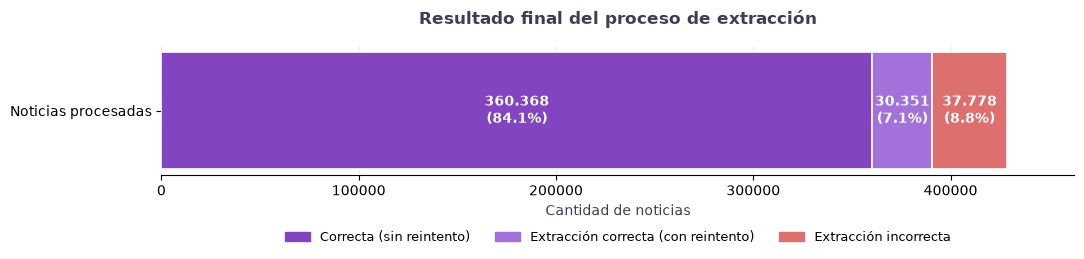

In [5]:
plot_df = pd.DataFrame({
    "Componente": [
        "Correcta (sin reintento)",
        "Extracción correcta (con reintento)",
        "Extracción incorrecta",
    ],
    "Cantidad": [
        success_direct,
        recovered_retry,
        total_invalid,
    ],
    "Color": [
        COLORS["violet_500"],
        COLORS["violet_400"],
        COLORS["secondary_300"],
    ],
})

fig, ax = plt.subplots(figsize=(11, 2.8))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

left = 0
bars = []

for _, row in plot_df.iterrows():
    bar = ax.barh(
        ["Noticias procesadas"],
        [row["Cantidad"]],
        left=left,
        color=row["Color"],
        edgecolor="white",
        linewidth=1.2,
        height=0.4,
    )

    bars.append((bar[0], row))
    left += row["Cantidad"]

for bar, row in bars:
    value = row["Cantidad"]
    pct = 100 * value / processed_total
    x = bar.get_x() + bar.get_width() / 2
    y = bar.get_y() + bar.get_height() / 2
    width = bar.get_width()

    ax.text(
        x, y,
        f"{fmt_int(value)}\n({pct:.1f}%)",
        va="center",
        ha="center",
        fontsize=10,
        color="white",
        fontweight="bold",
    )

ax.set_title(
    "Resultado final del proceso de extracción",
    fontsize=12,
    color=COLORS["text"],
    pad=16,
    fontweight="bold",
)

ax.set_xlabel("Cantidad de noticias", fontsize=10, color=COLORS["text"])
ax.set_ylabel("")
ax.grid(
    axis="x",
    color=COLORS["grid"],
    linewidth=0.8,
    alpha=0.8,
)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.set_xlim(
    0,
    processed_total * 1.08,
)

legend_handles = [
    plt.Rectangle(
        (0, 0),
        1,
        1,
        color=plot_df.iloc[i]["Color"],
    )
    for i in range(len(plot_df))
]

ax.legend(
    legend_handles,
    plot_df["Componente"],
    loc="upper center",
    bbox_to_anchor=(0.5, -0.34),
    ncol=3,
    frameon=False,
    fontsize=9,
)

fig.subplots_adjust(
    left=0.15,
    right=0.98,
    top=0.82,
    bottom=0.36,
)

save_figure(
    fig,
    "01_resultado_global_extraccion.png",
)

plt.show()

La distribución obtenida confirma que la estrategia basada en capturas periódicas de páginas de entrada permitió recuperar de forma sistemática un volumen considerable de contenidos a lo largo del periodo analizado y para las distintas fuentes. El resultado es especialmente relevante desde el punto de vista metodológico, ya que muestra que fue posible sustituir una estrategia de recuperación directa poco escalable por un procedimiento de adquisición más eficiente, manteniendo una cobertura temporal y documental adecuada para los objetivos del estudio. La estrategia desarrollada permitió, por tanto, superar una de las principales limitaciones técnicas identificadas durante la construcción del corpus sin requerir infraestructura computacional adicional.

### 2.1 Análisis de resultados no válidos

Registros "no válidos”: son registros de articles_contextual_unique.parquet que no cumplen simultáneamente estas dos condiciones:
1. tienen text no vacío;
2. no tienen fetch_error.

La distribución de estos casos se observa a continuación:

In [6]:
# ------------------------------------------------------------
# 1. Diagnóstico técnico de los registros procesados
# ------------------------------------------------------------

raw_extraction_breakdown = pd.DataFrame({
    "Motivo": list(
        raw_quality_counts.keys()
    ),
    "Registros": list(
        raw_quality_counts.values()
    ),
})

raw_extraction_breakdown[
    "Porcentaje"
] = (
    100
    * raw_extraction_breakdown["Registros"]
    / raw_processed_total
)

display(
    raw_extraction_breakdown.round(2)
)

,Motivo,Registros,Porcentaje
0,Evaluable: texto válido y sin error,390719,91.18
1,"No evaluable: sin texto, sin fetch_error",36,0.01
2,"No evaluable: con texto, con fetch_error",0,0.00
3,No evaluable: sin texto y con fetch_error,37742,8.81


### 2.2 Evolución de la tasa de éxito de extracción

El interés de este análisis se centra en:

$$
\text{Tasa de éxito de extracción}
=
100 \times
\frac{\text{noticias con texto válido}}
{\text{noticias observadas}}
$$

Las tasas correspondientes a combinaciones con muy pocos registros deben interpretarse junto con sus denominadores.

In [7]:
coverage_by_year_source = (
    run_summary
    .groupby(
        ["archive_year", "country", "source", "newspaper"],
        as_index=False,
        dropna=False,
    )
    .agg(
        Noticias_observadas=("Registros_procesados", "sum"),
        Noticias_con_texto_valido=("Extracciones_validas", "sum"),
    )
)

coverage_by_year_source["Tasa_extraccion_pct"] = (
    100
    * coverage_by_year_source["Noticias_con_texto_valido"]
    / coverage_by_year_source["Noticias_observadas"]
)

display(coverage_by_year_source)

,archive_year,country,source,newspaper,Noticias_observadas,Noticias_con_texto_valido,Tasa_extraccion_pct
0,2015,Argentina,clarin_arg,Clarín,7491,7203,96.16
1,2015,Argentina,lanacion,La Nación,27,18,66.67
2,2015,Argentina,pagina12,Página/12,4634,4336,93.57
3,2015,México,eluniversal_mx,El Universal,6411,4511,70.36
4,2015,México,jornada,La Jornada,21,14,66.67
5,2015,México,milenio,Milenio,17279,14777,85.52
6,2016,Argentina,clarin_arg,Clarín,13841,13404,96.84
7,2016,Argentina,lanacion,La Nación,6,6,100.00
8,2016,Argentina,pagina12,Página/12,10560,9818,92.97
9,2016,México,jornada,La Jornada,204,35,17.16


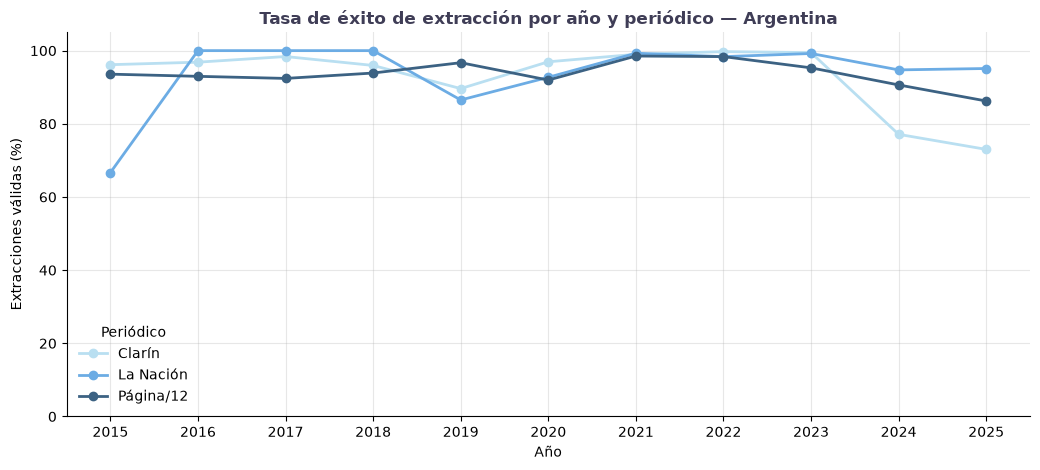

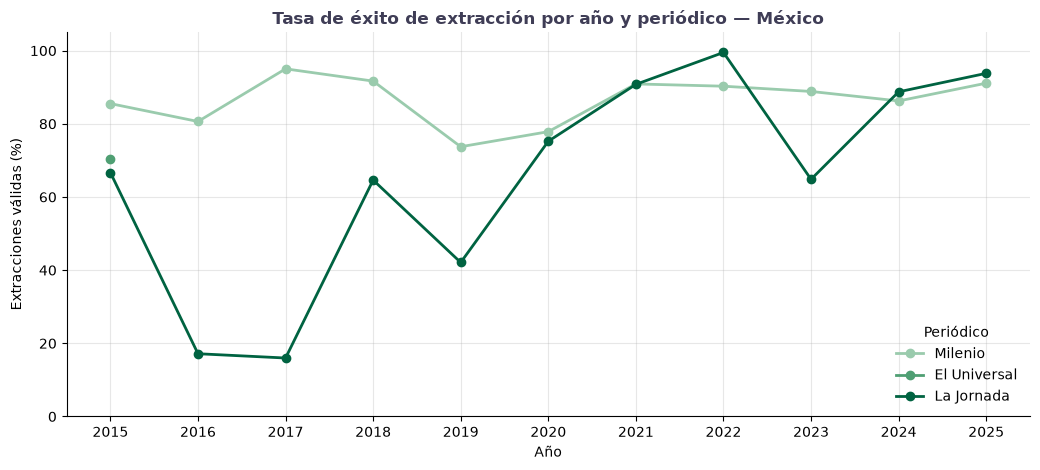

In [8]:
def plot_extraction_rate_country(data, country):
    subset = (
        data.loc[
            data["country"].eq(country)
        ]
        .copy()
    )

    fig, ax = plt.subplots(
        figsize=(10.5, 4.8)
    )

    for newspaper in SOURCE_ORDER[country]:
        tmp = (
            subset.loc[
                subset["newspaper"].eq(
                    newspaper
                )
            ]
            .set_index("archive_year")
            .reindex(
                range(
                    START_YEAR,
                    END_YEAR + 1,
                )
            )
        )

        ax.plot(
            tmp.index,
            tmp["Tasa_extraccion_pct"],
            marker="o",
            linewidth=2,
            label=newspaper,
            color=NEWSPAPER_COLOR[
                newspaper
            ],
        )

    ax.set_title(
        f"Tasa de éxito de extracción por año y periódico — {country}",
        fontsize=12,
        fontweight="bold",
        color=COLORS["text"],
    )

    ax.set_xlabel("Año")
    ax.set_ylabel("Extracciones válidas (%)")

    ax.set_xticks(
        range(
            START_YEAR,
            END_YEAR + 1,
        )
    )
    ax.set_ylim(0, 105)

    ax.grid(
        alpha=0.3
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        title="Periódico",
        frameon=False,
    )

    fig.tight_layout()

    save_figure(
        fig,
        f"03_tasa_extraccion_{country.lower().replace('é', 'e')}.png",
    )

    plt.show()


plot_extraction_rate_country(
    coverage_by_year_source,
    "Argentina",
)

plot_extraction_rate_country(
    coverage_by_year_source,
    "México",
)

archive_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
newspaper,,,,,,,,,,,
Clarín,96.20,96.80,98.40,95.90,89.60,96.90,99.00,99.70,99.50,77.10,73.00
La Nación,66.70,100.00,100.00,100.00,86.50,92.70,99.30,98.40,99.20,94.70,95.10
Página/12,93.60,93.00,92.40,93.90,96.70,92.00,98.50,98.40,95.30,90.60,86.20
Milenio,85.50,80.60,95.00,91.70,73.70,77.90,90.90,90.30,88.80,86.20,91.10
El Universal,70.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
La Jornada,66.70,17.20,16.00,64.60,42.10,75.20,90.80,99.50,64.80,88.70,93.80


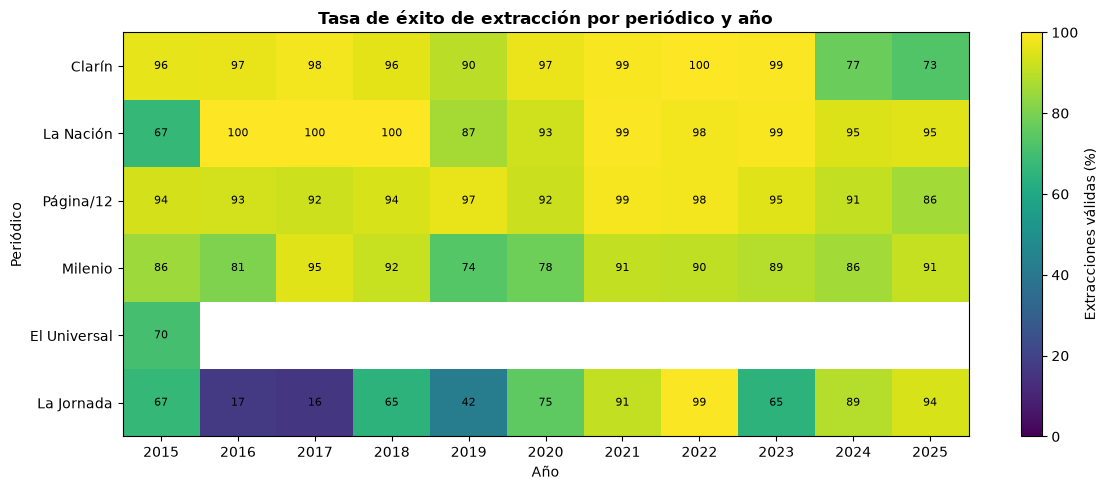

In [9]:
rate_heatmap = (
    coverage_by_year_source
    .pivot_table(
        index="newspaper",
        columns="archive_year",
        values="Tasa_extraccion_pct",
        aggfunc="mean",
    )
    .reindex(
        index=ALL_NEWSPAPERS,
        columns=range(
            START_YEAR,
            END_YEAR + 1,
        ),
    )
)

display(
    rate_heatmap.round(1)
)

fig, ax = plt.subplots(
    figsize=(12, 5)
)

masked = np.ma.masked_invalid(
    rate_heatmap.to_numpy(
        dtype=float
    )
)

im = ax.imshow(
    masked,
    aspect="auto",
    vmin=0,
    vmax=100,
)

ax.set_title(
    "Tasa de éxito de extracción por periódico y año",
    fontsize=12,
    fontweight="bold",
)

ax.set_xlabel("Año")
ax.set_ylabel("Periódico")

ax.set_xticks(
    np.arange(
        len(rate_heatmap.columns)
    )
)
ax.set_xticklabels(
    rate_heatmap.columns
)

ax.set_yticks(
    np.arange(
        len(rate_heatmap.index)
    )
)
ax.set_yticklabels(
    rate_heatmap.index
)

for i in range(
    len(rate_heatmap.index)
):
    for j in range(
        len(rate_heatmap.columns)
    ):
        value = rate_heatmap.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=8,
            )

cbar = fig.colorbar(
    im,
    ax=ax,
)
cbar.set_label(
    "Extracciones válidas (%)"
)

fig.tight_layout()

save_figure(
    fig,
    "04_heatmap_tasa_extraccion.png",
)

plt.show()

### 2.3 Continuidad temporal de la adquisición

Para cada combinación periódico–año se cuenta el número de meses con **al menos una extracción válida**, es decir, se observa el número de meses de cada año en los que el periódico tuvo al menos una extracción válida.

Esta medida es complementaria al volumen: un año con muchas noticias concentradas en pocos meses no ofrece la misma continuidad temporal que uno con presencia en los doce meses.

archive_year,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
newspaper,,,,,,,,,,,
Clarín,12,12,12,12,12,12,12,12,12,11,12
La Nación,9,6,12,12,10,12,12,12,12,11,12
Página/12,11,12,12,12,12,12,12,12,12,11,12
Milenio,11,11,12,12,12,12,12,12,12,11,12
El Universal,7,0,0,0,0,0,0,0,0,0,0
La Jornada,3,6,7,12,12,12,12,11,12,11,12


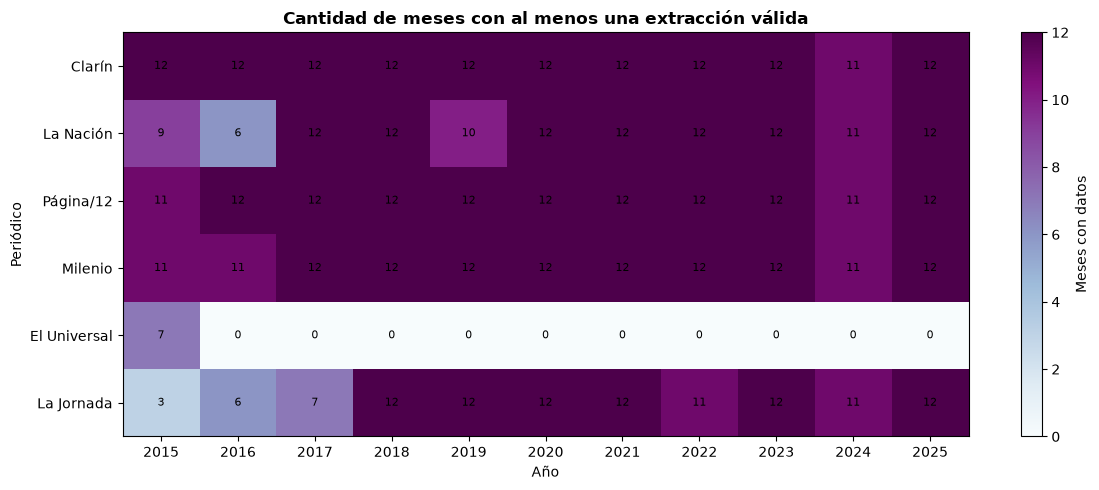

In [10]:
months_with_data = (
    run_summary.loc[
        run_summary["Extracciones_validas"] > 0
    ]
    .groupby(
        ["newspaper", "archive_year"],
        as_index=False,
    )["archive_month"]
    .nunique()
    .rename(
        columns={
            "archive_month": "Meses_con_texto_valido"
        }
    )
)

months_heatmap = (
    months_with_data
    .pivot(
        index="newspaper",
        columns="archive_year",
        values="Meses_con_texto_valido",
    )
    .reindex(
        index=ALL_NEWSPAPERS,
        columns=range(
            START_YEAR,
            END_YEAR + 1,
        ),
    )
    .fillna(0)
)

display(months_heatmap.astype(int))

fig, ax = plt.subplots(
    figsize=(12, 5)
)

im = ax.imshow(
    months_heatmap.to_numpy(
        dtype=float
    ),
    aspect="auto",
    cmap="BuPu",
    vmin=0,
    vmax=12,
)

ax.set_title(
    "Cantidad de meses con al menos una extracción válida",
    fontsize=12,
    fontweight="bold",
)

ax.set_xlabel("Año")
ax.set_ylabel("Periódico")

ax.set_xticks(
    np.arange(
        len(months_heatmap.columns)
    )
)
ax.set_xticklabels(
    months_heatmap.columns
)

ax.set_yticks(
    np.arange(
        len(months_heatmap.index)
    )
)
ax.set_yticklabels(
    months_heatmap.index
)

for i in range(
    len(months_heatmap.index)
):
    for j in range(
        len(months_heatmap.columns)
    ):
        value = int(
            months_heatmap.iloc[i, j]
        )

        ax.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=8,
        )

cbar = fig.colorbar(
    im,
    ax=ax,
)
cbar.set_label(
    "Meses con datos"
)

fig.tight_layout()

save_figure(
    fig,
    "05_heatmap_cobertura_mensual.png",
)

plt.show()

## 3. Consolidación del universo documental

El rendimiento técnico anterior se refiere a **registros de extracción**: cada fila representa un registro procesado por el pipeline y, por tanto, todavía puede contener repeticiones de una misma noticia.

Antes de describir la cobertura temporal, la composición por país o periódico y la calidad de los textos, se cambia la unidad de análisis. Se utiliza el artefacto consolidado `articles_contextual_unique.parquet`, que reúne los documentos válidos únicos obtenidos después de la depuración y deduplicación.

A partir de esta sección, salvo que se indique expresamente lo contrario, **todos los recuentos y gráficos se calculan sobre el cuerpo documental consolidado**. De este modo se evita que una noticia recuperada más de una vez tenga un peso artificialmente mayor en las estadísticas descriptivas.

La secuencia conceptual es:

$$
428\,497\ \text{registros procesados}
\rightarrow
390\,719\ \text{extracciones válidas}\\
\rightarrow
372\,065\ \text{documentos únicos consolidados}.
$$


### 3.1 Deduplicación de las extracciones válidas

Sobre los resultados de extracciones válidas se observan y eliminan los registros duplicados detectados.

In [11]:
# ------------------------------------------------------------
# 9. Deduplicación y construcción del cuerpo consolidado
# ------------------------------------------------------------

duplicate_mask = (
    valid_extractions
    .duplicated(
        subset=DOC_KEY,
        keep="first",
    )
)

n_duplicates_removed = int(
    duplicate_mask.sum()
)

consolidated_documents = (
    valid_extractions.loc[
        ~duplicate_mask
    ]
    .copy()
    .reset_index(drop=True)
)

n_consolidated = len(
    consolidated_documents
)


# Controles del snapshot 2015–2025 actualmente analizado.
assert (
    n_duplicates_removed
    == 18_654
), (
    "El número de duplicados no coincide "
    "con el esperado para este snapshot."
)

assert (
    n_consolidated
    == 372_065
), (
    "El número de documentos consolidados no coincide "
    "con el esperado para este snapshot."
)

assert (
    n_consolidated
    + n_duplicates_removed
    == raw_valid_total
)


# ------------------------------------------------------------
# 10. Añadir etiquetas de fuente al cuerpo consolidado
# ------------------------------------------------------------

consolidated_documents = add_source_labels(
    consolidated_documents
)


# ------------------------------------------------------------
# 13. Resumen de la consolidación documental
# ------------------------------------------------------------

consolidation_summary = pd.DataFrame({
    "Etapa": [
        "Extracciones válidas",
        "Duplicados eliminados",
        "Documentos consolidados",
    ],
    "Documentos": [
        raw_valid_total,
        n_duplicates_removed,
        n_consolidated,
    ],
})

consolidation_summary[
    "Porcentaje_sobre_validas"
] = [
    100.0,
    safe_rate(
        n_duplicates_removed,
        raw_valid_total,
    ),
    safe_rate(
        n_consolidated,
        raw_valid_total,
    ),
]

display(
    consolidation_summary.round(2)
)

,Etapa,Documentos,Porcentaje_sobre_validas
0,Extracciones válidas,390719,100.00
1,Duplicados eliminados,18654,4.77
2,Documentos consolidados,372065,95.23


## 4. Distribución temporal, por país y por periódico

Esta sección describe **exclusivamente los  documentos únicos del cuerpo consolidado**. Por ello, los valores pueden diferir de los recuentos de extracciones válidas mostrados antes de la consolidación: las repeticiones ya no intervienen.

El objetivo es caracterizar qué volumen documental queda realmente disponible para las etapas posteriores del estudio.

newspaper,Clarín,La Nación,Página/12
archive_year,,,
2015,7176,2,4153
2016,13277,1,9569
2017,7777,1,100
2018,6429,3,61
2019,4303,611,51
2020,4395,537,35
2021,5697,261,59
2022,4681,916,82
2023,5761,23466,58


newspaper,Milenio,El Universal,La Jornada
archive_year,,,
2015,14516,4446,5
2016,14294,0,14
2017,11956,0,19
2018,6883,0,814
2019,2829,0,422
2020,3663,0,1235
2021,6230,0,30969
2022,13321,0,28320
2023,23532,0,786


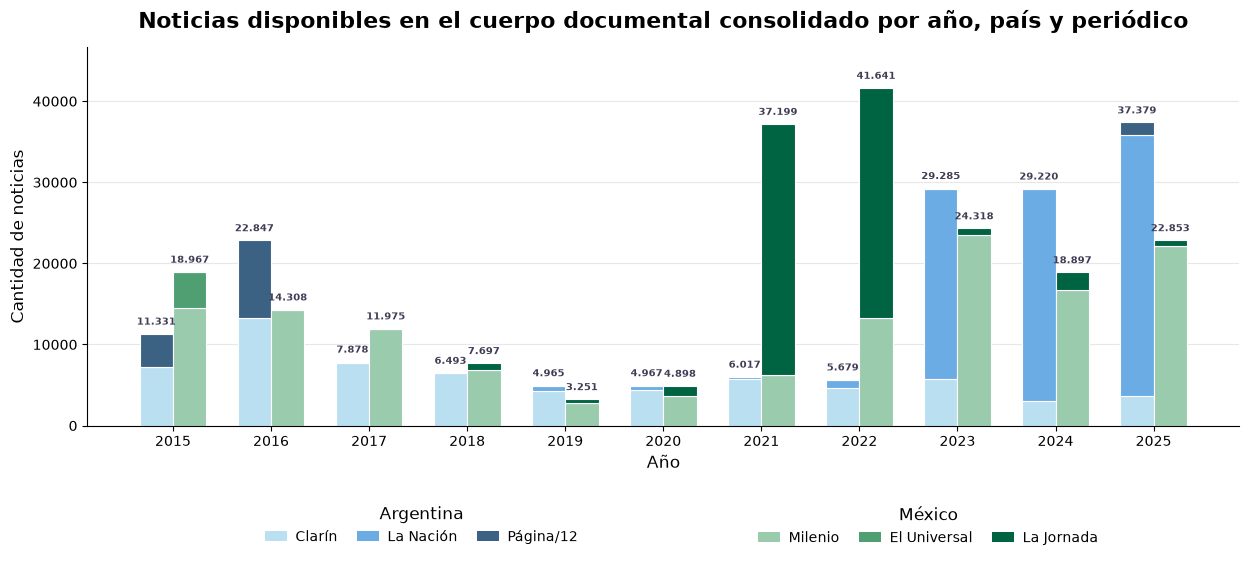

In [12]:
# ==========================================================
# Noticias disponibles en el cuerpo documental consolidado
# (372.065 registros técnicamente evaluables)
# ==========================================================

# Asegurar que el universo base sea el consolidado y evaluable
plot_data = consolidated_documents.copy()

# ----------------------------------------------------------
# Conteo por año, país y periódico
# ----------------------------------------------------------
available_by_year = (
    plot_data
    .groupby(
        ["country", "newspaper", "archive_year"],
        as_index=False
    )
    .size()
    .rename(columns={"size": "n_news"})
)

# ----------------------------------------------------------
# Construcción de tablas por país
# ----------------------------------------------------------
years = list(range(START_YEAR, END_YEAR + 1))

argentina_order = SOURCE_ORDER["Argentina"]
mexico_order = SOURCE_ORDER["México"]

argentina_table = (
    available_by_year.loc[
        available_by_year["country"] == "Argentina"
    ]
    .pivot(
        index="archive_year",
        columns="newspaper",
        values="n_news"
    )
    .reindex(
        index=years,
        columns=argentina_order
    )
    .fillna(0)
    .astype(int)
)

mexico_table = (
    available_by_year.loc[
        available_by_year["country"] == "México"
    ]
    .pivot(
        index="archive_year",
        columns="newspaper",
        values="n_news"
    )
    .reindex(
        index=years,
        columns=mexico_order
    )
    .fillna(0)
    .astype(int)
)

display(argentina_table)
display(mexico_table)

# ----------------------------------------------------------
# Totales por año
# ----------------------------------------------------------
argentina_totals = argentina_table.sum(axis=1)
mexico_totals = mexico_table.sum(axis=1)

# ----------------------------------------------------------
# Gráfico
# ----------------------------------------------------------
fig, ax = plt.subplots(figsize=(12.8, 6.2))

x = np.arange(len(years))
width = 0.34

# ======================================================
# ARGENTINA
# ======================================================
arg_bottom = np.zeros(len(years))
for newspaper, color in zip(
    argentina_order,
    SOURCE_COLORS["Argentina"]
):
    values = argentina_table[newspaper].to_numpy()
    ax.bar(
        x - width / 2,
        values,
        width=width,
        bottom=arg_bottom,
        label=newspaper,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        zorder=2,
    )
    arg_bottom += values

# ======================================================
# MÉXICO
# ======================================================
mx_bottom = np.zeros(len(years))
for newspaper, color in zip(
    mexico_order,
    SOURCE_COLORS["México"]
):
    values = mexico_table[newspaper].to_numpy()
    ax.bar(
        x + width / 2,
        values,
        width=width,
        bottom=mx_bottom,
        label=newspaper,
        color=color,
        edgecolor="white",
        linewidth=0.8,
        zorder=2,
    )
    mx_bottom += values

# ----------------------------------------------------------
# Etiquetas de total por barra
# ----------------------------------------------------------
max_country_total = max(
    arg_bottom.max() if len(arg_bottom) else 0,
    mx_bottom.max() if len(mx_bottom) else 0,
)

offset = max_country_total * 0.02 if max_country_total > 0 else 1

for i in range(len(years)):
    if arg_bottom[i] > 0:
        ax.text(
            x[i] - width / 2,
            arg_bottom[i] + offset,
            fmt_int(arg_bottom[i]),
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
            color=COLORS["text"],
        )

    if mx_bottom[i] > 0:
        ax.text(
            x[i] + width / 2,
            mx_bottom[i] + offset,
            fmt_int(mx_bottom[i]),
            ha="center",
            va="bottom",
            fontsize=7,
            fontweight="bold",
            color=COLORS["text"],
        )

if max_country_total > 0:
    ax.set_ylim(0, max_country_total * 1.12)

# ----------------------------------------------------------
# Ejes y formato
# ----------------------------------------------------------
ax.set_title(
    "Noticias disponibles en el cuerpo documental consolidado por año, país y periódico",
    fontsize=16,
    fontweight="bold",
    pad=14,
)

ax.set_xlabel("Año", fontsize=12)
ax.set_ylabel("Cantidad de noticias", fontsize=12)

ax.set_xticks(x)
ax.set_xticklabels(years)

ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)


# ======================================================
# LEYENDAS
# ======================================================
arg_handles = [
    Patch(
        facecolor=color,
        edgecolor="none",
        label=label,
    )
    for color, label in zip(
        SOURCE_COLORS["Argentina"],
        SOURCE_ORDER["Argentina"],
    )
]

mx_handles = [
    Patch(
        facecolor=color,
        edgecolor="none",
        label=label,
    )
    for color, label in zip(
        SOURCE_COLORS["México"],
        SOURCE_ORDER["México"],
    )
]

leg1 = ax.legend(
    handles=arg_handles,
    title="Argentina",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.29, -0.18),
    frameon=False,
    fontsize=10,
    title_fontsize=12,
    handlelength=1.6,
    handletextpad=0.6,
    columnspacing=1.4,
)

ax.add_artist(leg1)

ax.legend(
    handles=mx_handles,
    title="México",
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.73, -0.18),
    frameon=False,
    fontsize=10,
    title_fontsize=12,
    handlelength=1.6,
    handletextpad=0.6,
    columnspacing=1.4,
)

fig.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.88,
    bottom=0.27,
)
save_figure(
    fig,
    "noticias_disponibles_corpus_consolidado_anio_pais_periodico.png",
)

plt.show()

In [13]:
# ==========================================================
# Total del cuerpo documental consolidado por país
# ==========================================================

consolidated_by_country = (
    consolidated_documents
    .groupby(
        "country",
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "Noticias"
        }
    )
)

consolidated_by_country[
    "Porcentaje"
] = (
    100
    * consolidated_by_country["Noticias"]
    / len(consolidated_documents)
)

# Total general
total_row = pd.DataFrame({
    "country": ["Total"],
    "Noticias": [len(consolidated_documents)],
    "Porcentaje": [100.0],
})

consolidated_by_country = pd.concat(
    [
        consolidated_by_country,
        total_row,
    ],
    ignore_index=True,
)

display(
    consolidated_by_country.round(2)
)

,country,Noticias,Porcentaje
0,Argentina,166061,44.63
1,México,206004,55.37
2,Total,372065,100.00


In [14]:
# ==========================================================
# Cuerpo documental consolidado por año y país
# ==========================================================

consolidated_by_year_country = (
    consolidated_documents
    .groupby(
        [
            "archive_year",
            "country",
        ],
        as_index=False
    )
    .size()
    .rename(
        columns={
            "size": "Noticias"
        }
    )
)

consolidated_year_table = (
    consolidated_by_year_country
    .pivot(
        index="archive_year",
        columns="country",
        values="Noticias"
    )
    .fillna(0)
    .astype(int)
)

# Asegurar orden
consolidated_year_table = (
    consolidated_year_table
    .reindex(
        range(
            START_YEAR,
            END_YEAR + 1
        ),
        fill_value=0
    )
)

# Total anual
consolidated_year_table[
    "Total"
] = (
    consolidated_year_table.sum(
        axis=1
    )
)

# Total final
consolidated_year_table.loc[
    "Total"
] = (
    consolidated_year_table.sum(
        axis=0
    )
)

display(
    consolidated_year_table
)

country,Argentina,México,Total
archive_year,,,
2015,11331,18967,30298
2016,22847,14308,37155
2017,7878,11975,19853
2018,6493,7697,14190
2019,4965,3251,8216
2020,4967,4898,9865
2021,6017,37199,43216
2022,5679,41641,47320
2023,29285,24318,53603


## 5. Calidad técnica y completitud de los campos documentales en los textos recuperados

Una vez evaluada la calidad básica del contenido textual, se examina la información documental que acompañará a cada noticia durante las
etapas posteriores del análisis.

El objetivo de esta sección no es modificar nuevamente el corpus, sino documentar la calidad y trazabilidad de sus principales campos:
texto, título, URL y metadatos archivísticos. 

### 5.1 Distribución de longitud de los textos válidos

In [15]:
if "text" not in consolidated_documents.columns:
    raise KeyError("El cuerpo consolidado no contiene la columna 'text'.")

text_quality = consolidated_documents.loc[
    consolidated_documents["text"].fillna("").astype(str).str.strip().ne("")
].copy()

text_quality["n_palabras"] = (
    text_quality["text"]
    .fillna("")
    .astype(str)
    .str.findall(r"\b\w+\b")
    .str.len()
)

quality_summary = pd.DataFrame({
    "Indicador": [
        "Documentos únicos con texto evaluados",
        "Mediana de palabras",
        "Media de palabras",
        "Percentil 5",
        "Percentil 95",
        "Percentil 99",
    ],
    "Valor": [
        len(text_quality),
        text_quality["n_palabras"].median(),
        text_quality["n_palabras"].mean(),
        text_quality["n_palabras"].quantile(0.05),
        text_quality["n_palabras"].quantile(0.95),
        text_quality["n_palabras"].quantile(0.99),
    ],
})

display(quality_summary)

,Indicador,Valor
0,Documentos únicos con texto evaluados,"372,065.00"
1,Mediana de palabras,494.00
2,Media de palabras,631.96
3,Percentil 5,115.00
4,Percentil 95,"1,452.00"
5,Percentil 99,"2,856.00"


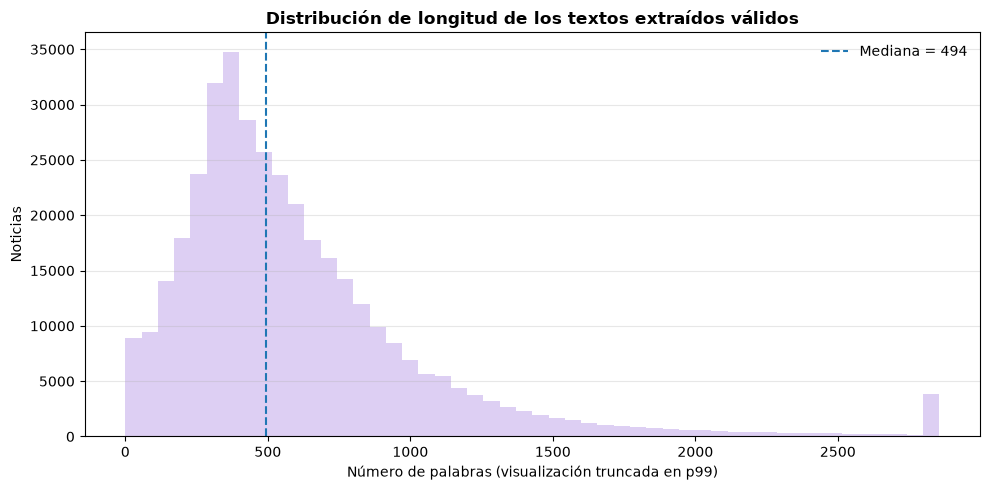

In [16]:
p99 = (
    text_quality[
        "n_palabras"
    ]
    .quantile(0.99)
)

fig, ax = plt.subplots(
    figsize=(10, 5)
)

ax.hist(
    text_quality[
        "n_palabras"
    ].clip(upper=p99),
    bins=50,
    color=COLORS["violet_200"],
)

ax.axvline(
    text_quality[
        "n_palabras"
    ].median(),
    linestyle="--",
    linewidth=1.5,
    label=(
        "Mediana = "
        f"{text_quality['n_palabras'].median():.0f}"
    ),
)

ax.set_title(
    "Distribución de longitud de los textos extraídos válidos",
    fontsize=12,
    fontweight="bold",
)

ax.set_xlabel(
    "Número de palabras (visualización truncada en p99)"
)
ax.set_ylabel(
    "Noticias"
)

ax.grid(
    axis="y",
    alpha=0.3,
)

ax.legend(
    frameon=False
)

fig.tight_layout()

save_figure(
    fig,
    "06_distribucion_longitud_textos_extraidos.png",
)

plt.show()

### 5.2 Mediana de palabras por periódico

,country,newspaper,Mediana_palabras
4,México,La Jornada,386.00
5,México,Milenio,396.00
3,México,El Universal,409.00
0,Argentina,Clarín,580.00
2,Argentina,Página/12,655.00
1,Argentina,La Nación,747.00


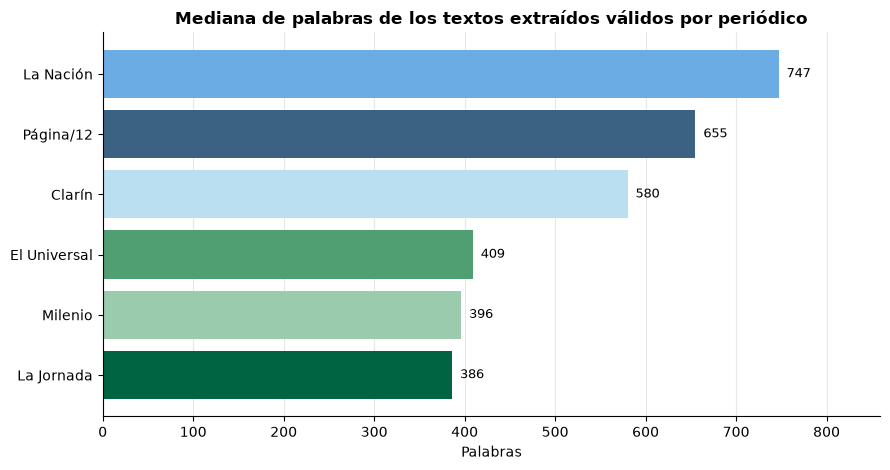

In [17]:
median_words_by_source = (
    text_quality
    .groupby(
        ["country", "newspaper"],
        as_index=False,
    )["n_palabras"]
    .median()
    .rename(
        columns={
            "n_palabras": "Mediana_palabras"
        }
    )
    .sort_values(
        "Mediana_palabras",
        ascending=True,
    )
)

display(median_words_by_source)

bar_colors = [
    NEWSPAPER_COLOR.get(
        newspaper,
        COLORS["secondary_300"],
    )
    for newspaper
    in median_words_by_source[
        "newspaper"
    ]
]

fig, ax = plt.subplots(
    figsize=(9, 4.8)
)

bars = ax.barh(
    median_words_by_source[
        "newspaper"
    ],
    median_words_by_source[
        "Mediana_palabras"
    ],
    color=bar_colors,
)

for bar, value in zip(
    bars,
    median_words_by_source[
        "Mediana_palabras"
    ],
):
    ax.text(
        value,
        bar.get_y()
        + bar.get_height() / 2,
        f"  {value:.0f}",
        va="center",
        fontsize=9,
    )

ax.set_title(
    "Mediana de palabras de los textos extraídos válidos por periódico",
    fontsize=12,
    fontweight="bold",
)

ax.set_xlabel("Palabras")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.3,
)
ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_xlim(
    0,
    median_words_by_source[
        "Mediana_palabras"
    ].max() * 1.15,
)

fig.tight_layout()

save_figure(
    fig,
    "07_mediana_palabras_por_periodico.png",
)

plt.show()

### 5.3 Efecto de la limpieza sobre los campos documentales

La comparación se realiza por pares reales del pipeline. Además de la completitud
antes y después, se cuentan por separado los registros que pierden un valor y los
que lo ganan durante el procesamiento. Esto evita interpretar una diferencia de
formato como una pérdida documental.

In [18]:
def has_value(series):
    """True cuando el campo contiene un valor no nulo y no vacío."""
    if (
        pd.api.types.is_object_dtype(series)
        or pd.api.types.is_string_dtype(series)
    ):
        return (
            series
            .fillna("")
            .astype(str)
            .str.strip()
            .ne("")
        )

    return series.notna()

In [19]:
processing_pairs = [
    (
        "Título",
        "title_raw",
        "title_clean",
    ),
    (
        "Texto",
        "text_raw",
        "text_clean",
    ),
    (
        "URL",
        "candidate_url",
        "normalized_url",
    ),
]

processing_rows = []

for label, before_col, after_col in processing_pairs:

    if not {
        before_col,
        after_col,
    }.issubset(
        consolidated_documents.columns
    ):
        continue

    before = has_value(
        consolidated_documents[before_col]
    )

    after = has_value(
        consolidated_documents[after_col]
    )

    processing_rows.append({
        "Campo": label,
        "Columna_antes": before_col,
        "Columna_despues": after_col,
        "Con_dato_antes": int(before.sum()),
        "Con_dato_despues": int(after.sum()),
        "Pierden_dato": int((before & ~after).sum()),
        "Ganan_dato": int((~before & after).sum()),
        "Completitud_antes_pct": 100 * before.mean(),
        "Completitud_despues_pct": 100 * after.mean(),
    })

processing_effect = pd.DataFrame(
    processing_rows
)

display(
    processing_effect.round(2)
)

,Campo,Columna_antes,Columna_despues,Con_dato_antes,Con_dato_despues,Pierden_dato,Ganan_dato,Completitud_antes_pct,Completitud_despues_pct
0,URL,candidate_url,normalized_url,372065,372065,0,0,100.00,100.00


### 5.4 Calidad de codificación y texto normalizado

Se utilizan patrones de control para detectar indicios residuales de *mojibake* y 
algunas formas corruptas previamente identificadas.

La ausencia de estos patrones permite afirmar que **no permanecen problemas detectables
según estos controles**. No permite afirmar cuántos caracteres fueron corregidos si
no se conserva la versión anterior del texto.

In [20]:
BAD_ENCODING_PATTERN = r"Ã|Â|â|�|Ì"

BAD_CORPUS_TERMS = [
    "asà",
    "ahà",
    "mà",
    "Secretarìa",
    "ocurriò",
]


text_series = (
    consolidated_documents[
        "text"
    ]
    .fillna("")
    .astype(str)
)


bad_encoding_mask = (
    text_series
    .str.contains(
        BAD_ENCODING_PATTERN,
        regex=True,
        na=False,
    )
)


n_bad_encoding = int(
    bad_encoding_mask.sum()
)

n_bad_encoding_occurrences = int(
    text_series
    .str.count(
        BAD_ENCODING_PATTERN
    )
    .sum()
)

corrupt_term_rows = []

for term in BAD_CORPUS_TERMS:

    pattern = (
        rf"(?<!\w)"
        rf"{re.escape(term)}"
        rf"(?!\w)"
    )

    affected = (
        text_series
        .str.contains(
            pattern,
            case=False,
            regex=True,
            na=False,
        )
    )

    corrupt_term_rows.append({
        "Forma":
            term,
        "Textos_afectados":
            int(
                affected.sum()
            ),
    })


corrupt_terms_summary = pd.DataFrame(
    corrupt_term_rows
)

n_known_corrupt = int(
    corrupt_terms_summary[
        "Textos_afectados"
    ].sum()
)


encoding_summary = pd.DataFrame({
    "Indicador": [
        "Textos evaluados",
        "Textos con indicios de mojibake",
        "Apariciones de caracteres sospechosos",
        "Textos con formas corruptas conocidas",
    ],
    "Valor": [
        len(consolidated_documents),
        n_bad_encoding,
        n_bad_encoding_occurrences,
        n_known_corrupt,
    ],
})

display(
    encoding_summary
)

display(
    corrupt_terms_summary
)

,Indicador,Valor
0,Textos evaluados,372065
1,Textos con indicios de mojibake,64410
2,Apariciones de caracteres sospechosos,3526771
3,Textos con formas corruptas conocidas,4


,Forma,Textos_afectados
0,asà,0
1,ahà,0
2,mà,0
3,Secretarìa,2
4,ocurriò,2


### 5.5 Efecto observable de la normalización de URL

`candidate_url` y `normalized_url` están presentes simultáneamente en el artefacto.
Se cuantifica cuántas representaciones cambiaron durante la canonicalización. Esto
no implica que la URL original fuese incorrecta.

In [21]:
url_normalization_summary = None

if {
    "candidate_url",
    "normalized_url",
}.issubset(
    consolidated_documents.columns
):

    original = (
        consolidated_documents[
            "candidate_url"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    normalized = (
        consolidated_documents[
            "normalized_url"
        ]
        .fillna("")
        .astype(str)
        .str.strip()
    )

    comparable = (
        original.ne("")
        & normalized.ne("")
    )

    changed = (
        comparable
        & original.ne(normalized)
    )

    url_normalization_summary = pd.DataFrame({
        "Indicador": [
            "Registros con ambas URL disponibles",
            "URL modificadas por normalización",
            "URL sin cambio observable",
            "URL modificadas (%)",
        ],
        "Valor": [
            int(comparable.sum()),
            int(changed.sum()),
            int(comparable.sum() - changed.sum()),
            safe_rate(
                int(changed.sum()),
                int(comparable.sum()),
            ),
        ],
    })

    display(
        url_normalization_summary
    )

,Indicador,Valor
0,Registros con ambas URL disponibles,"372,065.00"
1,URL modificadas por normalización,"348,171.00"
2,URL sin cambio observable,"23,894.00"
3,URL modificadas (%),93.58


### 5.6 Disponibilidad y procedencia del título

El título requiere un tratamiento separado. Se conserva el título extraído y limpio
cuando existe (`title_clean`). Si está vacío, se utiliza `anchor_text` **sólo** cuando
no es una etiqueta genérica y la URL no corresponde a los patrones conocidos de
páginas índice o multimedia.

Así se distinguen tres estados mutuamente excluyentes:

1. **Título extraído**: disponible directamente después de la extracción/limpieza.
2. **Título recuperado desde texto ancla**: no había título extraído, pero existe un
   texto ancla utilizable según las reglas de calidad.
3. **Título no resuelto**: no se dispone de ninguno de los anteriores.

La procedencia se conserva en `analysis_title_source`; por tanto, la barra apilada
representa el origen del título analítico y no confunde ausencia de título HTML con
ausencia final de información de título.

In [22]:
consolidated_documents.columns

Index(['source', 'country', 'snapshot_timestamp', 'homepage_url',
       'candidate_url', 'anchor_text', 'normalized_url', 'fetch_error',
       'html_path', 'title', 'text', 'text_length', 'html_found',
       'metadata_title', 'metadata_title_source', 'metadata_publication_date',
       'metadata_publication_date_source', 'metadata_title_effective',
       'metadata_title_effective_source', 'title_enriched',
       'title_enriched_source', 'publication_date',
       'publication_date_enriched', 'publication_date_enriched_source',
       'metadata_publication_date_method_trusted',
       'metadata_publication_date_temporally_valid',
       'metadata_publication_date_status', 'archive_year', 'archive_month',
       'run_id', 'newspaper'],
      dtype='str')

In [23]:
GENERIC_ANCHORS = {
    "",
    "inicio",
    "portada",
    "home",
    "multimedia",
    "rosario/12",
    "ver",
    "ver más",
    "leer",
    "leer más",
    "más información",
    "últimas noticias",
    "noticias",
}

NON_ARTICLE_URL_PATTERNS = [
    r"/index(?:-\d{4}-\d{2}-\d{2})?\.html(?:$|\?)",
    r"/multimedia/?(?:$|\?)",
]


def normalize_field(series):
    return (
        series
        .fillna("")
        .astype(str)
        .str.replace(
            r"\s+",
            " ",
            regex=True,
        )
        .str.strip()
    )


assert_columns(
    consolidated_documents,
    [
        "title_enriched",
        "anchor_text",
        "normalized_url",
    ],
    "consolidated_documents",
)

extracted_title = normalize_field(
    consolidated_documents[
        "title_enriched"
    ]
)

anchor = normalize_field(
    consolidated_documents[
        "anchor_text"
    ]
)

url_for_title = (
    normalize_field(
        consolidated_documents[
            "normalized_url"
        ]
    )
    .str.lower()
)

anchor_is_generic = (
    anchor
    .str.lower()
    .isin(
        GENERIC_ANCHORS
    )
)

probable_non_article_url = pd.Series(
    False,
    index=consolidated_documents.index,
)

for pattern in NON_ARTICLE_URL_PATTERNS:
    probable_non_article_url = (
        probable_non_article_url
        | url_for_title.str.contains(
            pattern,
            regex=True,
            na=False,
        )
    )

missing_extracted_title = (
    extracted_title.eq("")
)

usable_anchor = (
    missing_extracted_title
    & anchor.ne("")
    & ~anchor_is_generic
    & ~probable_non_article_url
)

unresolved_title = (
    missing_extracted_title
    & ~usable_anchor
)

consolidated_documents[
    "analysis_title"
] = extracted_title

consolidated_documents[
    "analysis_title_source"
] = "html_extracted"

consolidated_documents.loc[
    usable_anchor,
    "analysis_title",
] = anchor.loc[
    usable_anchor
]

consolidated_documents.loc[
    usable_anchor,
    "analysis_title_source",
] = "anchor_text"

consolidated_documents.loc[
    unresolved_title,
    "analysis_title",
] = ""

consolidated_documents.loc[
    unresolved_title,
    "analysis_title_source",
] = "missing_or_generic"

consolidated_documents[
    "analysis_title_available"
] = (
    consolidated_documents[
        "analysis_title"
    ]
    .ne("")
)

consolidated_documents[
    "anchor_is_generic"
] = anchor_is_generic

consolidated_documents[
    "probable_non_article_url"
] = probable_non_article_url


TITLE_SOURCE_LABELS = {
    "html_extracted": "Título extraído",
    "anchor_text": "Título recuperado desde texto ancla",
    "missing_or_generic": "Título no resuelto",
}

title_source_summary = (
    consolidated_documents[
        "analysis_title_source"
    ]
    .value_counts()
    .rename_axis(
        "Origen"
    )
    .reset_index(
        name="Noticias"
    )
)

title_source_summary[
    "Etiqueta"
] = (
    title_source_summary[
        "Origen"
    ]
    .map(
        TITLE_SOURCE_LABELS
    )
)

title_source_summary[
    "Porcentaje"
] = (
    100
    * title_source_summary[
        "Noticias"
    ]
    / len(consolidated_documents)
)

display(
    title_source_summary[
        [
            "Etiqueta",
            "Noticias",
            "Porcentaje",
        ]
    ]
    .round(2)
)

,Etiqueta,Noticias,Porcentaje
0,Título extraído,366310,98.45
1,Título recuperado desde texto ancla,5108,1.37
2,Título no resuelto,647,0.17


In [24]:
title_by_source = (
    consolidated_documents
    .groupby(
        [
            "country",
            "newspaper",
            "analysis_title_source",
        ],
        as_index=False,
    )
    .size()
    .rename(
        columns={
            "size": "Noticias"
        }
    )
)

title_totals = (
    title_by_source
    .groupby(
        [
            "country",
            "newspaper",
        ],
        as_index=False,
    )["Noticias"]
    .sum()
    .rename(
        columns={
            "Noticias": "Total"
        }
    )
)

title_by_source = (
    title_by_source
    .merge(
        title_totals,
        on=[
            "country",
            "newspaper",
        ],
        how="left",
    )
)

title_by_source[
    "Porcentaje"
] = (
    100
    * title_by_source[
        "Noticias"
    ]
    / title_by_source[
        "Total"
    ]
)

# Tabla ancha para el gráfico 100 % apilado.
title_plot = (
    title_by_source
    .pivot_table(
        index=[
            "country",
            "newspaper",
        ],
        columns="analysis_title_source",
        values="Porcentaje",
        aggfunc="sum",
        fill_value=0,
    )
    .reset_index()
)

for source_name in [
    "html_extracted",
    "anchor_text",
    "missing_or_generic",
]:
    if source_name not in title_plot.columns:
        title_plot[source_name] = 0.0

newspaper_order = (
    SOURCE_ORDER["Argentina"]
    + SOURCE_ORDER["México"]
)

title_plot[
    "newspaper"
] = pd.Categorical(
    title_plot[
        "newspaper"
    ],
    categories=newspaper_order,
    ordered=True,
)

title_plot = (
    title_plot
    .sort_values("newspaper")
    .reset_index(drop=True)
)

display(
    title_plot[
        [
            "country",
            "newspaper",
            "html_extracted",
            "anchor_text",
            "missing_or_generic",
        ]
    ]
    .rename(
        columns={
            "html_extracted": "Título extraído (%)",
            "anchor_text": "Título recuperado (%)",
            "missing_or_generic": "Título no resuelto (%)",
        }
    )
    .round(2)
)

analysis_title_source,country,newspaper,Título extraído (%),Título recuperado (%),Título no resuelto (%)
0,Argentina,Clarín,99.99,0.01,0.00
1,Argentina,La Nación,100.00,0.00,0.00
2,Argentina,Página/12,63.62,32.27,4.11
3,México,Milenio,100.00,0.00,0.00
4,México,El Universal,100.00,0.00,0.00
5,México,La Jornada,99.97,0.03,0.00


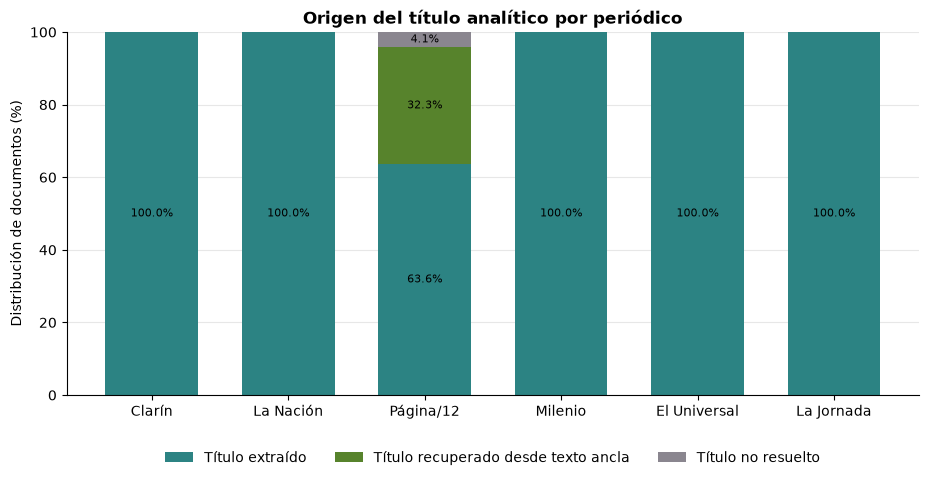

In [25]:
fig, ax = plt.subplots(
    figsize=(11, 5.5)
)

x = np.arange(
    len(title_plot)
)

bottom = np.zeros(
    len(title_plot)
)

stack_specs = [
    (
        "html_extracted",
        "Título extraído",
        COLORS["quaternary_400"],
    ),
    (
        "anchor_text",
        "Título recuperado desde texto ancla",
        COLORS["tertiary_400"],
    ),
    (
        "missing_or_generic",
        "Título no resuelto",
        COLORS["quinary_400"],
    ),
]

for col, label, color in stack_specs:

    values = (
        title_plot[col]
        .to_numpy(dtype=float)
    )

    bars = ax.bar(
        x,
        values,
        bottom=bottom,
        label=label,
        color=color,
        width=0.68,
    )

    for bar, value, base in zip(
        bars,
        values,
        bottom,
    ):
        if value >= 3:
            ax.text(
                bar.get_x()
                + bar.get_width() / 2,
                base + value / 2,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    bottom = bottom + values

ax.set_title(
    "Origen del título analítico por periódico",
    fontsize=12,
    fontweight="bold",
)

ax.set_ylabel(
    "Distribución de documentos (%)"
)
ax.set_xlabel("")
ax.set_xticks(x)
ax.set_xticklabels(
    title_plot[
        "newspaper"
    ]
)
ax.set_ylim(0, 100)
ax.grid(
    axis="y",
    alpha=0.3,
)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
)
fig.subplots_adjust(bottom=0.22)

save_figure(
    fig,
    "02_origen_titulo_por_periodico.png",
)

plt.show()

### 5.7 Trazabilidad archivística

Estos campos documentan la trazabilidad de Wayback Machine. No deben interpretarse
como fechas verificadas de publicación de la noticia.

In [26]:
archive_metadata_rows = []

for column, label in [
    (
        "snapshot_datetime",
        "Fecha de la captura utilizada",
    ),
    (
        "first_snapshot_datetime",
        "Primera captura observada",
    ),
    (
        "last_snapshot_datetime",
        "Última captura observada",
    ),
    (
        "snapshot_count",
        "Número de capturas observadas",
    ),
    (
        "archive_year",
        "Año de archivo",
    ),
]:

    if column not in consolidated_documents.columns:
        continue

    available = has_value(
        consolidated_documents[column]
    )

    archive_metadata_rows.append({
        "Metadato": label,
        "Columna": column,
        "Con_dato": int(available.sum()),
        "Sin_dato": int((~available).sum()),
        "Completitud_pct": 100 * available.mean(),
    })

archive_metadata_summary = pd.DataFrame(
    archive_metadata_rows
)

display(
    archive_metadata_summary.round(2)
)


archive_checks = []

if {
    "first_snapshot_datetime",
    "snapshot_datetime",
}.issubset(consolidated_documents.columns):
    archive_checks.append({
        "Control": "Primera captura <= captura utilizada",
        "Inconsistencias": int((
            consolidated_documents[
                "first_snapshot_datetime"
            ]
            > consolidated_documents[
                "snapshot_datetime"
            ]
        ).sum()),
    })

if {
    "snapshot_datetime",
    "last_snapshot_datetime",
}.issubset(consolidated_documents.columns):
    archive_checks.append({
        "Control": "Captura utilizada <= última captura",
        "Inconsistencias": int((
            consolidated_documents[
                "snapshot_datetime"
            ]
            > consolidated_documents[
                "last_snapshot_datetime"
            ]
        ).sum()),
    })

if "snapshot_count" in consolidated_documents.columns:
    archive_checks.append({
        "Control": "snapshot_count >= 1",
        "Inconsistencias": int((
            consolidated_documents[
                "snapshot_count"
            ] < 1
        ).sum()),
    })

if {
    "snapshot_datetime",
    "archive_year",
}.issubset(consolidated_documents.columns):
    archive_checks.append({
        "Control": "archive_year coincide con el año de snapshot_datetime",
        "Inconsistencias": int((
            consolidated_documents[
                "archive_year"
            ].astype("Int64")
            != consolidated_documents[
                "snapshot_datetime"
            ].dt.year.astype("Int64")
        ).sum()),
    })

archive_consistency = pd.DataFrame(
    archive_checks
)

display(
    archive_consistency
)

,Metadato,Columna,Con_dato,Sin_dato,Completitud_pct
0,Año de archivo,archive_year,372065,0,100.00


""


## 6. Evaluación de la información temporal

El análisis longitudinal del tratamiento mediático requiere disponer de una
referencia temporal suficientemente fiable para cada documento. Sin embargo,
la fecha de captura registrada por Internet Archive no necesariamente coincide
con la fecha original de publicación de la noticia.

Por este motivo, antes de utilizar el año como variable analítica se evalúa la
disponibilidad, procedencia y coherencia de las fechas de publicación recuperadas.

El análisis se realiza sobre el cuerpo documental consolidado, compuesto por
372.065 documentos únicos. Se distingue entre la fecha candidata recuperada
durante la extracción y la fecha finalmente aceptada por el procedimiento de
validación temporal.

In [27]:
# ==========================================================
# Preparación de variables temporales
# ==========================================================

date_df = consolidated_documents.copy()

required_columns = [
    "source",
    "country",
    "newspaper",
    "archive_year",
    "archive_month",
    "snapshot_timestamp",
    "metadata_publication_date",
    "metadata_publication_date_source",
    "publication_date_enriched",
    "publication_date_enriched_source",
    "metadata_publication_date_method_trusted",
    "metadata_publication_date_temporally_valid",
    "metadata_publication_date_status",
]

assert_columns(
    date_df,
    required_columns,
    "consolidated_documents",
)

# ----------------------------------------------------------
# Fecha de captura
# ----------------------------------------------------------

date_df["snapshot_datetime"] = pd.to_datetime(
    date_df["snapshot_timestamp"].astype("string"),
    format="%Y%m%d%H%M%S",
    errors="coerce",
    utc=True,
)

# ----------------------------------------------------------
# Fecha candidata recuperada
# ----------------------------------------------------------

date_df["metadata_publication_datetime"] = pd.to_datetime(
    date_df["metadata_publication_date"],
    format="mixed",
    errors="coerce",
    utc=True,
)

# ----------------------------------------------------------
# Fecha finalmente aceptada
# ----------------------------------------------------------

date_df["publication_datetime"] = pd.to_datetime(
    date_df["publication_date_enriched"],
    format="mixed",
    errors="coerce",
    utc=True,
)

date_df["publication_date_accepted"] = (
    date_df["metadata_publication_date_status"]
    .eq("accepted")
)

date_df["has_publication_date"] = (
    date_df["publication_datetime"].notna()
)

# Una fecha aceptada debe ser exactamente una fecha utilizable.
assert (
    date_df["publication_date_accepted"]
    == date_df["has_publication_date"]
).all()

# ----------------------------------------------------------
# Variables derivadas
# ----------------------------------------------------------

date_df["snapshot_year"] = (
    date_df["snapshot_datetime"].dt.year
)

date_df["publication_year"] = (
    date_df["publication_datetime"].dt.year
)

date_df["publication_snapshot_delta_days"] = (
    (
        date_df["snapshot_datetime"]
        - date_df["publication_datetime"]
    )
    .dt.total_seconds()
    / 86400
)

n_documents = len(date_df)

assert n_documents == 372_065

print(
    "Documentos consolidados:",
    f"{n_documents:,}",
)

Documentos consolidados: 372,065


### 6.1 Disponibilidad de fecha de publicación

La fecha de captura de Wayback Machine no coincide necesariamente con la fecha original de publicación de una noticia. Antes de realizar análisis longitudinales, se evaluó la disponibilidad, procedencia y coherencia de las fechas de publicación recuperadas. Este análisis se realizó sobre los 372.065 documentos únicos que conforman el cuerpo documental consolidado.

In [28]:
metadata_nonempty = (
    date_df["metadata_publication_date"]
    .fillna("")
    .astype(str)
    .str.strip()
    .ne("")
)

metadata_parseable = (
    date_df["metadata_publication_datetime"]
    .notna()
)

accepted = (
    date_df["publication_date_accepted"]
)

date_availability = pd.DataFrame({
    "Estado": [
        "Cuerpo documental consolidado",
        "Fecha candidata recuperada",
        "Fecha candidata parseable",
        "Fecha de publicación aceptada",
        "Sin fecha de publicación aceptada",
    ],
    "Documentos": [
        n_documents,
        int(metadata_nonempty.sum()),
        int(metadata_parseable.sum()),
        int(accepted.sum()),
        int((~accepted).sum()),
    ],
})

date_availability["Porcentaje"] = (
    100
    * date_availability["Documentos"]
    / n_documents
)

display(
    date_availability.round(2)
)

,Estado,Documentos,Porcentaje
0,Cuerpo documental consolidado,372065,100.00
1,Fecha candidata recuperada,313079,84.15
2,Fecha candidata parseable,312103,83.88
3,Fecha de publicación aceptada,257286,69.15
4,Sin fecha de publicación aceptada,114779,30.85


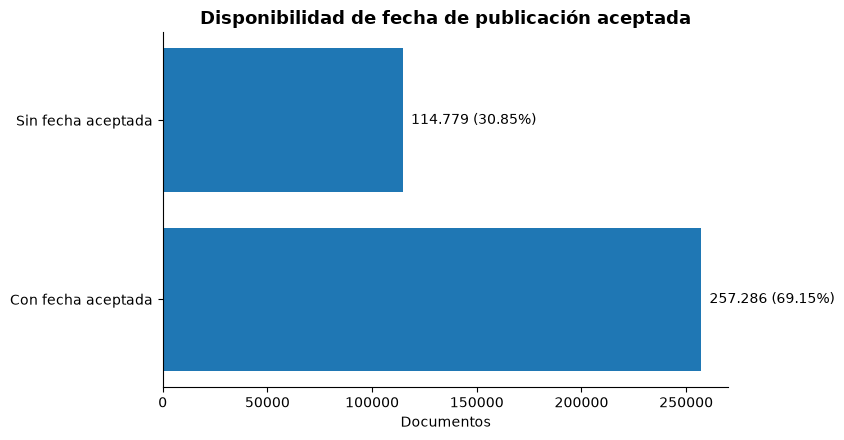

In [29]:
date_final_status = pd.DataFrame({
    "Estado": [
        "Con fecha aceptada",
        "Sin fecha aceptada",
    ],
    "Documentos": [
        int(accepted.sum()),
        int((~accepted).sum()),
    ],
})

date_final_status["Porcentaje"] = (
    100
    * date_final_status["Documentos"]
    / n_documents
)

fig, ax = plt.subplots(
    figsize=(8.5, 4.5)
)

bars = ax.barh(
    date_final_status["Estado"],
    date_final_status["Documentos"],
)

for bar, (_, row) in zip(
    bars,
    date_final_status.iterrows(),
):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        (
            f"  {fmt_int(row['Documentos'])} "
            f"({row['Porcentaje']:.2f}%)"
        ),
        va="center",
        fontsize=10,
    )

ax.set_title(
    "Disponibilidad de fecha de publicación aceptada",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel("Documentos")
ax.set_ylabel("")

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

save_figure(
    fig,
    "disponibilidad_fecha_publicacion.png",
)

plt.show()

### 6.2 Procedencia de la fecha

La fecha de publicación no procede de un único mecanismo de extracción. Dependiendo de la estructura de cada página, puede recuperarse desde elementos temporales del HTML, metadatos de fecha o estructuras JSON-LD.

Por ello se conserva explícitamente la procedencia de cada valor. Esta información permite auditar la heterogeneidad de los métodos de recuperación y evitar tratar todas las fechas como observaciones equivalentes sin conocer su origen.

#### 6.2.1 Validación de fechas

In [30]:
date_status_summary = (
    date_df[
        "metadata_publication_date_status"
    ]
    .fillna("missing")
    .replace("", "missing")
    .value_counts(dropna=False)
    .rename_axis("Estado")
    .reset_index(name="Documentos")
)

date_status_summary["Porcentaje"] = (
    100
    * date_status_summary["Documentos"]
    / n_documents
)

display(
    date_status_summary.round(2)
)

,Estado,Documentos,Porcentaje
0,accepted,257286,69.15
1,missing,58986,15.85
2,rejected_untrusted_method,54099,14.54
3,rejected_after_capture,1694,0.46


#### 6.2.2 Fuente de las fechas aceptadas

In [31]:
accepted_dates = (
    date_df.loc[
        date_df["publication_date_accepted"]
    ]
    .copy()
)

n_accepted = len(
    accepted_dates
)

date_source_summary = (
    accepted_dates[
        "publication_date_enriched_source"
    ]
    .fillna("missing")
    .replace("", "missing")
    .value_counts(dropna=False)
    .rename_axis("Fuente_fecha")
    .reset_index(name="Documentos")
)

date_source_summary["Porcentaje"] = (
    100
    * date_source_summary["Documentos"]
    / n_accepted
)

display(
    date_source_summary.round(2)
)

,Fuente_fecha,Documentos,Porcentaje
0,jsonld_datePublished,256411,99.66
1,article_published_time,875,0.34


#### 6.2.3 Control de las fechas no parseables

In [32]:
unparseable_metadata_dates = date_df.loc[
    metadata_nonempty
    & ~metadata_parseable,
    [
        "source",
        "newspaper",
        "archive_year",
        "metadata_publication_date",
        "metadata_publication_date_source",
        "metadata_publication_date_status",
    ],
].copy()

print(
    "Fechas candidatas no parseables:",
    f"{len(unparseable_metadata_dates):,}",
)

print(
    "No parseables aceptadas:",
    f"{unparseable_metadata_dates['metadata_publication_date_status'].eq('accepted').sum():,}",
)

assert (
    unparseable_metadata_dates[
        "metadata_publication_date_status"
    ]
    .eq("accepted")
    .sum()
    == 0
)

display(
    unparseable_metadata_dates.head(20)
)

Fechas candidatas no parseables: 976
No parseables aceptadas: 0


,source,newspaper,archive_year,metadata_publication_date,metadata_publication_date_source,metadata_publication_date_status
118277,lanacion,La Nación,2020,28 de junio de 2021,time_datetime,rejected_untrusted_method
118285,lanacion,La Nación,2020,18 de Noviembre de 2020,time_datetime,rejected_untrusted_method
119924,lanacion,La Nación,2021,31 de Diciembre de 2020,time_datetime,rejected_untrusted_method
119960,lanacion,La Nación,2021,5 de marzo de 2021,time_datetime,rejected_untrusted_method
121732,lanacion,La Nación,2021,20 de marzo de 2021,time_datetime,rejected_untrusted_method
121750,lanacion,La Nación,2021,18 de mayo de 2021,time_datetime,rejected_untrusted_method
121760,lanacion,La Nación,2021,26 de marzo de 2021,time_datetime,rejected_untrusted_method
121762,lanacion,La Nación,2021,9 de septiembre de 2021,time_datetime,rejected_untrusted_method
121769,lanacion,La Nación,2021,22 de febrero de 2021,time_datetime,rejected_untrusted_method
121782,lanacion,La Nación,2021,9 de abril de 2021,time_datetime,rejected_untrusted_method


### 6.3 Cobertura temporal por medio y año

#### 6.3.1 cobertura por periódico

In [33]:
date_coverage_source = (
    date_df
    .groupby(
        [
            "country",
            "newspaper",
        ],
        as_index=False,
    )
    .agg(
        Documentos=(
            "normalized_url",
            "size",
        ),
        Con_fecha=(
            "publication_date_accepted",
            "sum",
        ),
    )
)

date_coverage_source["Sin_fecha"] = (
    date_coverage_source["Documentos"]
    - date_coverage_source["Con_fecha"]
)

date_coverage_source["Cobertura_pct"] = (
    100
    * date_coverage_source["Con_fecha"]
    / date_coverage_source["Documentos"]
)

display(
    date_coverage_source.round(2)
)

,country,newspaper,Documentos,Con_fecha,Sin_fecha,Cobertura_pct
0,Argentina,Clarín,66157,33919,32238,51.27
1,Argentina,La Nación,84153,77138,7015,91.66
2,Argentina,Página/12,15751,0,15751,0.00
3,México,El Universal,4446,0,4446,0.00
4,México,La Jornada,65466,64281,1185,98.19
5,México,Milenio,136092,81948,54144,60.22


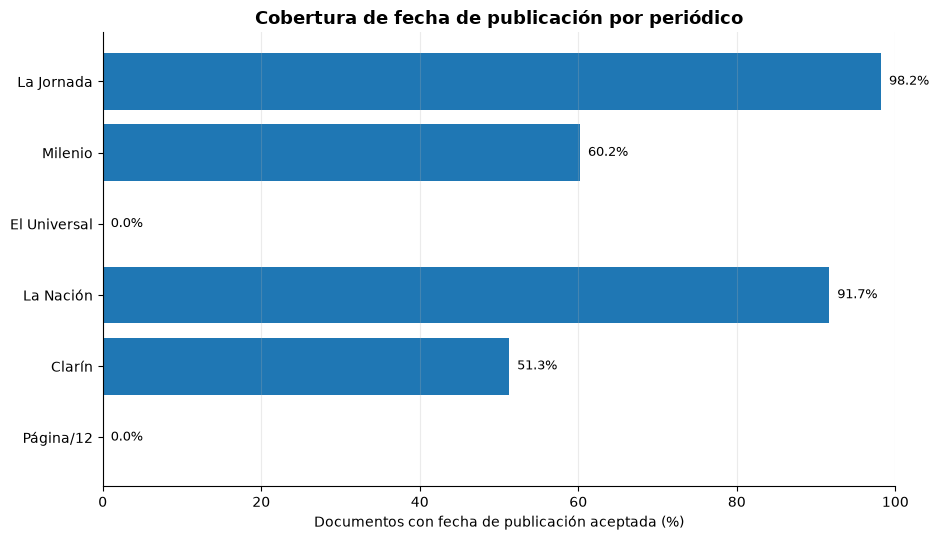

In [34]:
plot_data = (
    date_coverage_source
    .sort_values(
        [
            "country",
            "Cobertura_pct",
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(9.5, 5.5)
)

bars = ax.barh(
    plot_data["newspaper"],
    plot_data["Cobertura_pct"],
)

for bar, value in zip(
    bars,
    plot_data["Cobertura_pct"],
):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.1f}%",
        va="center",
        fontsize=9,
    )

ax.set_xlim(0, 100)

ax.set_title(
    "Cobertura de fecha de publicación por periódico",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel(
    "Documentos con fecha de publicación aceptada (%)"
)

ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

save_figure(
    fig,
    "cobertura_fecha_por_periodico.png",
)

plt.show()

#### 6.3.2 Cobertura por año

In [35]:
date_coverage_year = (
    date_df
    .groupby(
        "archive_year",
        as_index=False,
    )
    .agg(
        Documentos=(
            "normalized_url",
            "size",
        ),
        Con_fecha=(
            "publication_date_accepted",
            "sum",
        ),
    )
)

date_coverage_year["Cobertura_pct"] = (
    100
    * date_coverage_year["Con_fecha"]
    / date_coverage_year["Documentos"]
)

display(
    date_coverage_year.round(2)
)

,archive_year,Documentos,Con_fecha,Cobertura_pct
0,2015,30298,54,0.18
1,2016,37155,2677,7.20
2,2017,19853,176,0.89
3,2018,14190,2024,14.26
4,2019,8216,4172,50.78
5,2020,9865,6926,70.21
6,2021,43216,42575,98.52
7,2022,47320,46090,97.40
8,2023,53603,51181,95.48
9,2024,48117,45343,94.23


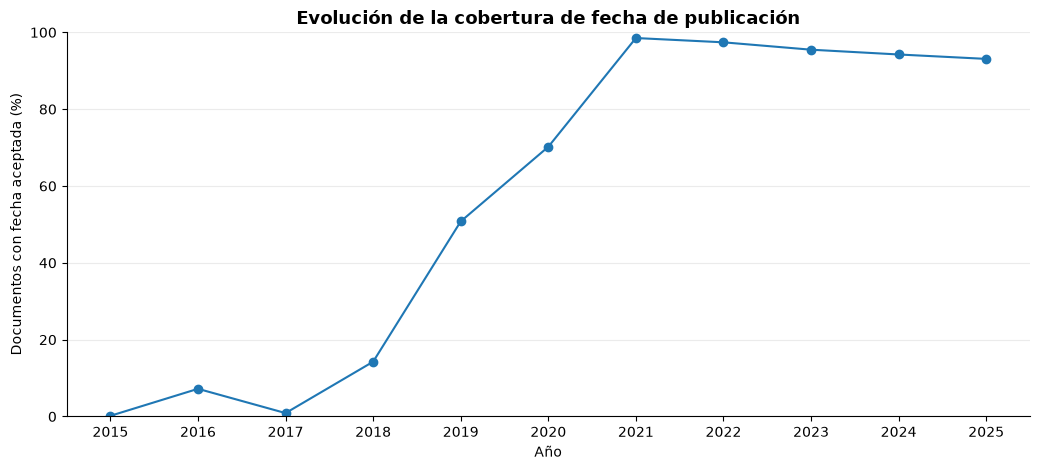

In [36]:
fig, ax = plt.subplots(
    figsize=(10.5, 4.8)
)

ax.plot(
    date_coverage_year["archive_year"],
    date_coverage_year["Cobertura_pct"],
    marker="o",
)

ax.set_ylim(0, 100)

ax.set_title(
    "Evolución de la cobertura de fecha de publicación",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel("Año")
ax.set_ylabel(
    "Documentos con fecha aceptada (%)"
)

ax.set_xticks(
    range(
        START_YEAR,
        END_YEAR + 1,
    )
)

ax.grid(
    axis="y",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

save_figure(
    fig,
    "cobertura_fecha_por_anio.png",
)

plt.show()

#### 6.3.3 Cobertura por medio y año

In [37]:
date_coverage_source_year = (
    date_df
    .groupby(
        [
            "newspaper",
            "archive_year",
        ],
        as_index=False,
    )
    .agg(
        Documentos=(
            "normalized_url",
            "size",
        ),
        Con_fecha=(
            "publication_date_accepted",
            "sum",
        ),
    )
)

date_coverage_source_year[
    "Cobertura_pct"
] = (
    100
    * date_coverage_source_year["Con_fecha"]
    / date_coverage_source_year["Documentos"]
)

date_heatmap = (
    date_coverage_source_year
    .pivot(
        index="newspaper",
        columns="archive_year",
        values="Cobertura_pct",
    )
    .reindex(
        index=ALL_NEWSPAPERS,
        columns=range(
            START_YEAR,
            END_YEAR + 1,
        ),
    )
)

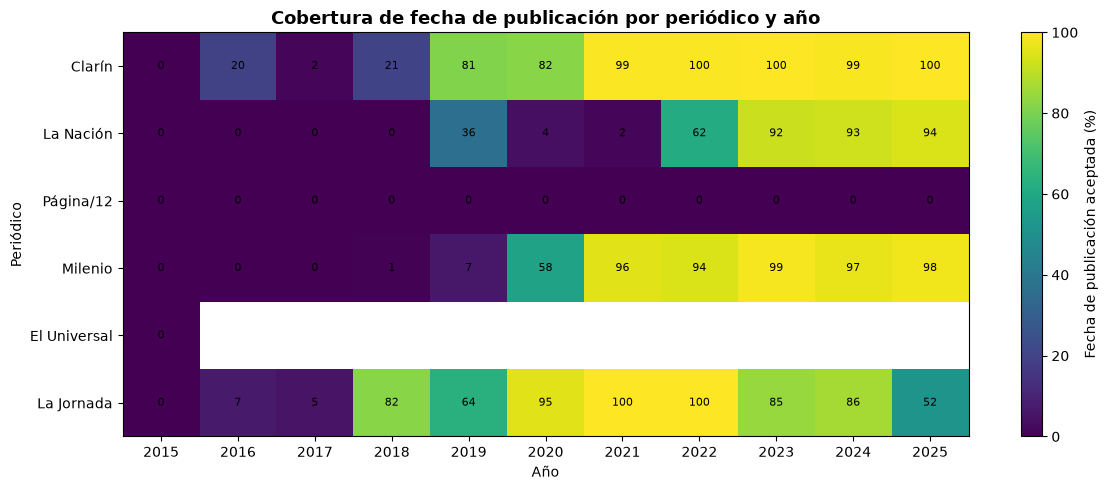

In [38]:
fig, ax = plt.subplots(
    figsize=(12, 5)
)

masked = np.ma.masked_invalid(
    date_heatmap.to_numpy(
        dtype=float
    )
)

im = ax.imshow(
    masked,
    aspect="auto",
    vmin=0,
    vmax=100,
)

ax.set_title(
    "Cobertura de fecha de publicación por periódico y año",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel("Año")
ax.set_ylabel("Periódico")

ax.set_xticks(
    np.arange(
        len(date_heatmap.columns)
    )
)

ax.set_xticklabels(
    date_heatmap.columns
)

ax.set_yticks(
    np.arange(
        len(date_heatmap.index)
    )
)

ax.set_yticklabels(
    date_heatmap.index
)

for i in range(
    len(date_heatmap.index)
):
    for j in range(
        len(date_heatmap.columns)
    ):
        value = date_heatmap.iloc[i, j]

        if pd.notna(value):
            ax.text(
                j,
                i,
                f"{value:.0f}",
                ha="center",
                va="center",
                fontsize=8,
            )

cbar = fig.colorbar(
    im,
    ax=ax,
)

cbar.set_label(
    "Fecha de publicación aceptada (%)"
)

fig.tight_layout()

save_figure(
    fig,
    "cobertura_fecha_periodico_anio.png",
)

plt.show()

### 6.4 Coherencia entre publicación y captura

Una vez identificados los documentos con una fecha de publicación aceptada,
se examina su relación con la fecha de captura registrada por Internet Archive.
Este análisis permite comprobar si las fechas utilizadas son temporalmente
compatibles con el proceso de archivado.

A diferencia de los apartados anteriores, los porcentajes de esta sección se
calculan únicamente sobre los documentos con una fecha de publicación aceptada.

#### 6.4.1 Universo comparable

In [39]:
delta_valid = (
    date_df.loc[
        date_df["publication_date_accepted"]
        & date_df["snapshot_datetime"].notna()
    ]
    .copy()
)

n_comparable = len(
    delta_valid
)

print(
    "Documentos con fecha aceptada:",
    f"{n_accepted:,}",
)

print(
    "Documentos comparables con captura:",
    f"{n_comparable:,}",
)

Documentos con fecha aceptada: 257,286
Documentos comparables con captura: 257,286


#### 6.4.2 Desfase

In [40]:
delta_valid["capture_delay"] = pd.cut(
    delta_valid[
        "publication_snapshot_delta_days"
    ],
    bins=[
        -np.inf,
        0,
        1,
        7,
        30,
        365,
        np.inf,
    ],
    labels=[
        "Posterior a la captura",
        "< 1 día",
        "1–7 días",
        "8–30 días",
        "31–365 días",
        "> 1 año",
    ],
    right=False,
)

capture_delay_summary = (
    delta_valid[
        "capture_delay"
    ]
    .value_counts(sort=False)
    .rename_axis("Desfase")
    .reset_index(name="Documentos")
)

capture_delay_summary["Porcentaje"] = (
    100
    * capture_delay_summary["Documentos"]
    / n_comparable
)

display(
    capture_delay_summary.round(2)
)

,Desfase,Documentos,Porcentaje
0,Posterior a la captura,11951,4.65
1,< 1 día,215567,83.78
2,1–7 días,27691,10.76
3,8–30 días,522,0.20
4,31–365 días,1160,0.45
5,> 1 año,395,0.15


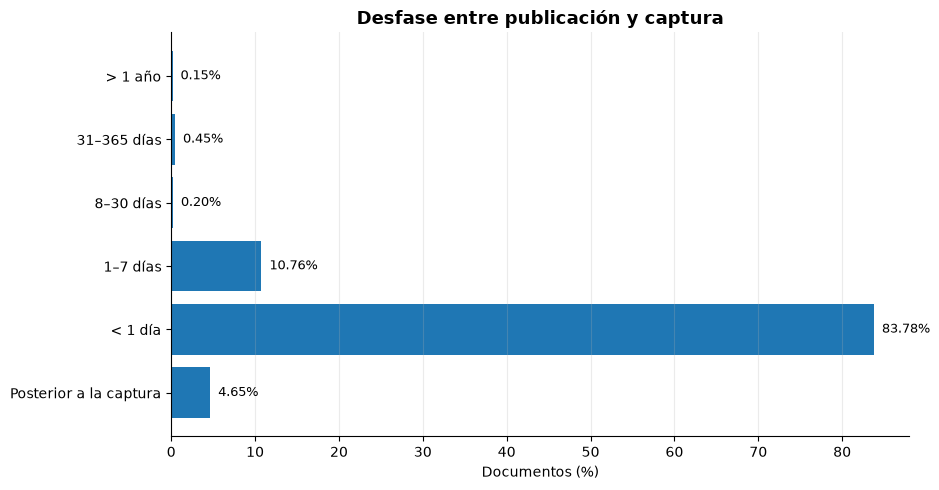

In [41]:
fig, ax = plt.subplots(
    figsize=(9.5, 5)
)

bars = ax.barh(
    capture_delay_summary["Desfase"].astype(str),
    capture_delay_summary["Porcentaje"],
)

for bar, value in zip(
    bars,
    capture_delay_summary["Porcentaje"],
):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f"  {value:.2f}%",
        va="center",
        fontsize=9,
    )

ax.set_title(
    "Desfase entre publicación y captura",
    fontsize=13,
    fontweight="bold",
)

ax.set_xlabel("Documentos (%)")
ax.set_ylabel("")

ax.grid(
    axis="x",
    alpha=0.25,
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.tight_layout()

save_figure(
    fig,
    "desfase_publicacion_captura.png",
)

plt.show()

Los 11.951 documentos cuya fecha de publicación aparece
como posterior a la captura presentan desfases inferiores a 24 horas. La
mediana del desfase es de aproximadamente 2,5 horas y el 73,9 % de los casos
se concentra por debajo de las 6 horas. Por tanto, estos casos corresponden
a discrepancias temporales de corta duración y no a diferencias de varios
días o periodos prolongados. Este comportamiento puede estar relacionado
con la representación horaria de las fechas recuperadas y de las capturas
archivadas, por lo que se documenta como una limitación de la comparación
temporal y no se corrige en esta etapa.

#### 6.4.3 Año de publicación vs. año de archivo

In [42]:
year_comparison = (
    date_df.loc[
        date_df["publication_date_accepted"]
        & date_df["publication_year"].notna()
    ]
    .copy()
)

year_comparison["year_difference"] = (
    year_comparison["archive_year"]
    - year_comparison["publication_year"]
)

year_difference_summary = (
    year_comparison["year_difference"]
    .value_counts()
    .sort_index()
    .rename_axis(
        "Diferencia_anios"
    )
    .reset_index(
        name="Documentos"
    )
)

year_difference_summary["Porcentaje"] = (
    100
    * year_difference_summary["Documentos"]
    / len(year_comparison)
)

display(
    year_difference_summary.round(2)
)

,Diferencia_anios,Documentos,Porcentaje
0,0.00,255673,99.37
1,1.00,1392,0.54
2,2.00,87,0.03
3,3.00,30,0.01
4,4.00,53,0.02
5,5.00,18,0.01
6,6.00,10,0.00
7,7.00,21,0.01
8,8.00,1,0.00
9,10.00,1,0.00


### 6.5. Resumen de la calidad de la información temporal

La evaluación anterior permite sintetizar la disponibilidad y el estado
de la información temporal recuperada durante la extracción. En esta etapa
no se corrigen las fechas rechazadas ni se establece todavía la referencia
temporal definitiva que utilizará el corpus de análisis.

In [43]:
# ==========================================================
# Resumen final de disponibilidad temporal
# ==========================================================

date_quality_summary = pd.DataFrame({
    "Estado": [
        "Fecha de publicación aceptada",
        "Sin fecha recuperada",
        "Fecha candidata de método no confiable",
        "Fecha candidata posterior a la captura",
    ],
    "Documentos": [
        int(
            date_df["metadata_publication_date_status"]
            .eq("accepted")
            .sum()
        ),
        int(
            date_df["metadata_publication_date_status"]
            .eq("missing")
            .sum()
        ),
        int(
            date_df["metadata_publication_date_status"]
            .eq("rejected_untrusted_method")
            .sum()
        ),
        int(
            date_df["metadata_publication_date_status"]
            .eq("rejected_after_capture")
            .sum()
        ),
    ],
})

date_quality_summary["Porcentaje"] = (
    100
    * date_quality_summary["Documentos"]
    / len(date_df)
)

display(
    date_quality_summary.round(2)
)

,Estado,Documentos,Porcentaje
0,Fecha de publicación aceptada,257286,69.15
1,Sin fecha recuperada,58986,15.85
2,Fecha candidata de método no confiable,54099,14.54
3,Fecha candidata posterior a la captura,1694,0.46


La extracción permitió obtener una fecha de publicación aceptada para el 69,15 % del cuerpo documental consolidado. La ausencia de una fecha aceptada en los registros restantes no implica necesariamente la ausencia de información temporal: una proporción relevante corresponde a fechas candidatas descartadas por los criterios de confianza o consistencia aplicados durante la extracción. Asimismo, se identificaron fechas candidatas expresadas en formatos textuales, incluidos formatos en español, que no son interpretados directamente por el procedimiento de normalización utilizado. Estas situaciones se documentan como limitaciones de la extracción y no se corrigen en esta etapa. La construcción posterior del corpus de análisis será la encargada de aplicar las reglas definitivas de normalización, priorización y selección de la referencia temporal.

# Conclusión

El resultado de esta etapa constituye el universo documental de entrada
para la preselección temática. Hasta este punto, los documentos han sido
seleccionados exclusivamente mediante criterios técnicos de adquisición,
consolidación y calidad documental; no se ha aplicado todavía ningún
criterio de relevancia respecto de la violencia machista.

El notebook 02 parte de este universo para aplicar las reglas de
preselección y clasificación temática.